# MagicAdjuster Tutorial

This notebook demonstrates how to use the `MagicAdjuster` class for statistical distribution fitting and analysis.

## Overview

`MagicAdjuster` is designed to:
- Fit statistical distributions to your data
- Perform goodness-of-fit tests (KS, Chi-square, RMSE)
- Provide seamless access to all SciPy distribution methods
- Run Monte Carlo stability analysis

## Setup and Data Generation

Let's start by importing the necessary libraries and generating some sample wind speed data.

In [15]:
import numpy as np
import matplotlib.pyplot as plt
import magica as ma
from magica.core import DataProcessor, MagicAdjuster

# Set random seed for reproducibility
np.random.seed(42)

# Generate sample wind speed data (Weibull-like distribution)
n_samples = 1000
wind_speeds = np.random.weibull(2, n_samples) * 8 + 2  # Scale and shift

print(f"Generated {n_samples} wind speed measurements")
print(f"Min: {wind_speeds.min():.2f} m/s")
print(f"Max: {wind_speeds.max():.2f} m/s")
print(f"Mean: {wind_speeds.mean():.2f} m/s")
print(f"Std: {wind_speeds.std():.2f} m/s")

Generated 1000 wind speed measurements
Min: 2.55 m/s
Max: 24.87 m/s
Mean: 8.97 m/s
Std: 3.69 m/s


## Basic Usage: Loading Data and Fitting a Distribution

In [16]:
# Load data using MagicA's DataProcessor
processor = ma.read_data(wind_speeds)
print(f"Loaded data: {processor}")

# Get basic statistics
stats = processor.get_basic_stats()
for key, value in stats.items():
    print(f"{key}: {value:.4f}")

Loaded data: DataProcessor(length=1000, dtype=float64)
count: 1000.0000
mean: 8.9709
std: 3.6961
var: 13.6609
min: 2.5451
max: 24.8700
median: 8.6298
q25: 6.1504
q75: 11.3426


In [17]:
# Fit a Weibull distribution (common for wind data)
processor.fit_distribution('weibull_min')
print(f"Updated processor: {processor}")

# Get fitted parameters
params = processor.get_fitted_params()
print(f"\nFitted Weibull parameters:")
print(f"Shape (c): {params[0]:.4f}")
print(f"Location (loc): {params[1]:.4f}")
print(f"Scale: {params[2]:.4f}")

# Get distribution info
info = processor.get_distribution_info()
print(f"\nDistribution info:")
for key, value in info.items():
    print(f"{key}: {value}")

Updated processor: DataProcessor(length=1000, dtype=float64, distribution='weibull_min')

Fitted Weibull parameters:
Shape (c): 1.8487
Location (loc): 2.3531
Scale: 7.4447

Distribution info:
name: weibull_min
parameters: (np.float64(1.8486974637812565), np.float64(2.3531115620951226), np.float64(7.4447412667075525))
num_params: 3
data_size: 1000


## Accessing SciPy Methods Directly

Once a distribution is fitted, you can access all SciPy distribution methods directly through the processor.

In [18]:
# Smart defaults: evaluate at original data points
pdf_values = processor.pdf()  # PDF at all original data points
cdf_values = processor.cdf()  # CDF at all original data points

print(f"PDF values (first 10): {pdf_values[:10]}")
print(f"CDF values (first 10): {cdf_values[:10]}")

# Custom inputs also work
prob_10ms = processor.cdf(10.0)  # P(wind speed ≤ 10 m/s)
percentile_95 = processor.ppf(0.95)  # 95th percentile wind speed

print(f"\nP(wind speed ≤ 10 m/s): {prob_10ms:.4f}")
print(f"95th percentile wind speed: {percentile_95:.2f} m/s")

# Generate random samples from fitted distribution
random_samples = processor.rvs(size=5)
print(f"5 random wind speed samples: {random_samples}")

PDF values (first 10): [0.10954842 0.0201954  0.07291156 0.09321379 0.09435054 0.09434594
 0.06364648 0.0442638  0.09290786 0.07711357]
CDF values (first 10): [0.39457944 0.95100694 0.74589473 0.6179072  0.16446916 0.16444297
 0.05686516 0.87194422 0.62029511 0.7231631 ]

P(wind speed ≤ 10 m/s): 0.6503
95th percentile wind speed: 15.83 m/s
5 random wind speed samples: [ 5.50995661  8.8646398  13.3681271  10.99571328 12.09096196]


## Goodness-of-Fit Testing

Evaluate how well the distribution fits your data using various statistical tests.

In [19]:
# Kolmogorov-Smirnov test
ks_result = processor.goodness_of_fit('ks')
print("Kolmogorov-Smirnov Test:")
print(f"  Statistic: {ks_result['ks_statistic']:.6f}")
print(f"  P-value: {ks_result['p_value']:.6f}")
print(f"  Result: {'Good fit' if ks_result['p_value'] > 0.05 else 'Poor fit'} (α = 0.05)")

# Chi-square test
chi2_result = processor.goodness_of_fit('chi2')
print("\nChi-square Test:")
print(f"  Statistic: {chi2_result['chi2_statistic']:.6f}")
print(f"  P-value: {chi2_result['p_value']:.6f}")
print(f"  Bins used: {chi2_result['n_bins']}")
print(f"  Result: {'Good fit' if chi2_result['p_value'] > 0.05 else 'Poor fit'} (α = 0.05)")

# RMSE
rmse = processor.goodness_of_fit('rmse')
print(f"\nRoot Mean Square Error: {rmse:.6f}")

Kolmogorov-Smirnov Test:
  Statistic: 0.022647
  P-value: 0.675447
  Result: Good fit (α = 0.05)

Chi-square Test:
  Statistic: 12.338939
  P-value: 0.500066
  Bins used: 14
  Result: Good fit (α = 0.05)

Root Mean Square Error: 0.007777


/home/daniloceano/Documents/Programs_and_scripts/MagicA/magica/core/magic_adjuster.py:467: UserWarning: Normalizing expected frequencies. Original sum: 998.407739, Target sum: 1000
  warnings.warn(f"Normalizing expected frequencies. Original sum: {expected_freq.sum():.6f}, "


### Understanding Chi-square Test and Number of Bins

The chi-square goodness-of-fit test compares observed frequencies in histogram bins with expected frequencies from the fitted distribution. The number of bins significantly affects the test results.

In [20]:
# Demonstrate different binning methods for chi-square test
binning_methods = ['doane', 'sturges', 'freedman-diaconis', 'rice', 'scott', 30]

print("Chi-square Test Results with Different Binning Methods:")
print("-" * 70)
print(f"{'Method':<20} {'Bins':<6} {'Chi2 Stat':<12} {'P-value':<12} {'Result'}")
print("-" * 70)

for method in binning_methods:
    chi2_result = processor.goodness_of_fit('chi2', bins=method)
    result_text = 'Good fit' if chi2_result['p_value'] > 0.05 else 'Poor fit'
    method_name = str(method) if isinstance(method, int) else method
    
    print(f"{method_name:<20} {chi2_result['n_bins']:<6} {chi2_result['chi2_statistic']:<12.4f} "
          f"{chi2_result['p_value']:<12.6f} {result_text}")

print("\nBinning Method Guidelines:")
print("- Doane: Best for skewed distributions (default)")
print("- Sturges: Good for normal distributions, conservative")
print("- Freedman-Diaconis: Robust for various distributions")
print("- Rice: Simple rule, scales with cube root of sample size")
print("- Scott: Minimizes integrated mean square error")
print("- Fixed number: Use when you need specific bin count")

Chi-square Test Results with Different Binning Methods:
----------------------------------------------------------------------
Method               Bins   Chi2 Stat    P-value      Result
----------------------------------------------------------------------
doane                14     12.3389      0.500066     Good fit
sturges              10     8.4626       0.488279     Good fit
freedman-diaconis    21     17.3856      0.627811     Good fit
rice                 19     10.8226      0.901733     Good fit
scott                17     19.6356      0.237085     Good fit
30                   30     29.3177      0.448617     Good fit

Binning Method Guidelines:
- Doane: Best for skewed distributions (default)
- Sturges: Good for normal distributions, conservative
- Freedman-Diaconis: Robust for various distributions
- Rice: Simple rule, scales with cube root of sample size
- Scott: Minimizes integrated mean square error
- Fixed number: Use when you need specific bin count


## Visualization: Comparing Data and Fitted Distribution

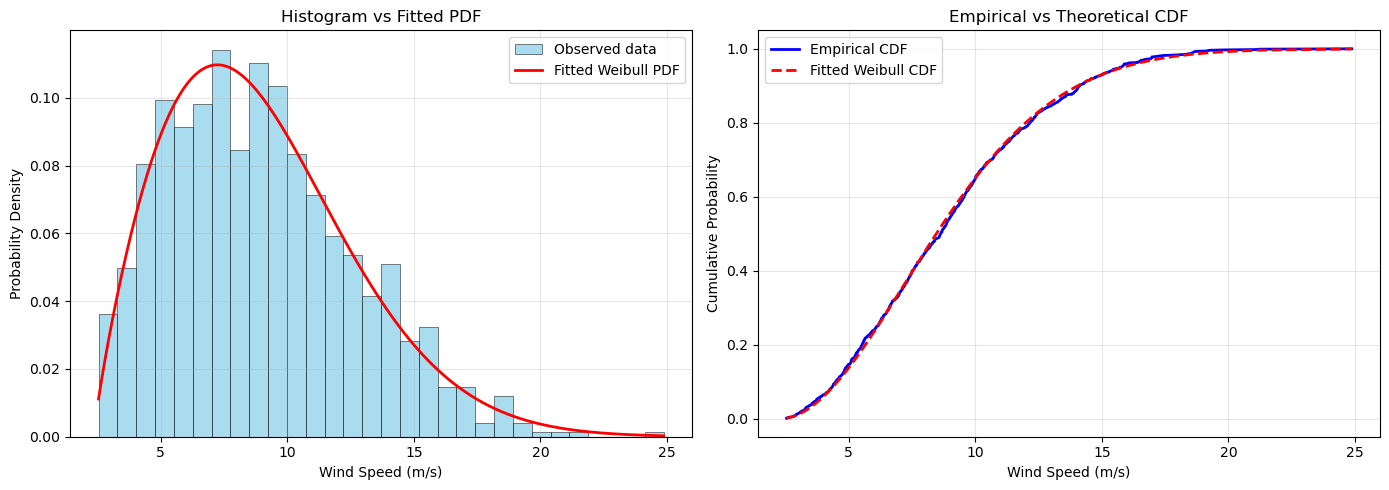

In [21]:
# Create comparison plots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Histogram with fitted PDF
ax1.hist(wind_speeds, bins=30, density=True, alpha=0.7, color='skyblue', 
         label='Observed data', edgecolor='black', linewidth=0.5)

# Generate smooth curve for fitted distribution
x_smooth = np.linspace(wind_speeds.min(), wind_speeds.max(), 1000)
pdf_smooth = processor.pdf(x_smooth)
ax1.plot(x_smooth, pdf_smooth, 'r-', linewidth=2, label='Fitted Weibull PDF')

ax1.set_xlabel('Wind Speed (m/s)')
ax1.set_ylabel('Probability Density')
ax1.set_title('Histogram vs Fitted PDF')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Plot 2: Empirical vs Theoretical CDF
sorted_data = np.sort(wind_speeds)
empirical_cdf = np.arange(1, len(sorted_data) + 1) / len(sorted_data)
theoretical_cdf = processor.cdf(sorted_data)

ax2.plot(sorted_data, empirical_cdf, 'b-', linewidth=2, label='Empirical CDF')
ax2.plot(sorted_data, theoretical_cdf, 'r--', linewidth=2, label='Fitted Weibull CDF')

ax2.set_xlabel('Wind Speed (m/s)')
ax2.set_ylabel('Cumulative Probability')
ax2.set_title('Empirical vs Theoretical CDF')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Using Different Distributions

Let's try fitting other distributions to see which one works best.

In [22]:
# Test different distributions
distributions_to_test = ['weibull_min', 'lognorm', 'gamma', 'norm', 'expon']
results = []

for dist_name in distributions_to_test:
    # Create a fresh processor for each distribution
    temp_processor = ma.read_data(wind_speeds)
    temp_processor.fit_distribution(dist_name)
    
    # Calculate goodness-of-fit metrics
    ks_test = temp_processor.goodness_of_fit('ks')
    rmse = temp_processor.goodness_of_fit('rmse')
    
    results.append({
        'distribution': dist_name,
        'ks_pvalue': ks_test['p_value'],
        'rmse': rmse,
        'parameters': temp_processor.get_fitted_params()
    })

# Display results
print("Distribution Comparison:")
print("-" * 60)
print(f"{'Distribution':<15} {'KS p-value':<12} {'RMSE':<10} {'Fit Quality'}")
print("-" * 60)

for result in results:
    quality = "Good" if result['ks_pvalue'] > 0.05 else "Poor"
    print(f"{result['distribution']:<15} {result['ks_pvalue']:<12.6f} {result['rmse']:<10.6f} {quality}")

# Find best distribution (highest KS p-value)
best_result = max(results, key=lambda x: x['ks_pvalue'])
print(f"\nBest distribution: {best_result['distribution']} (KS p-value: {best_result['ks_pvalue']:.6f})")

Distribution Comparison:
------------------------------------------------------------
Distribution    KS p-value   RMSE       Fit Quality
------------------------------------------------------------
weibull_min     0.675447     0.007777   Good
lognorm         0.220995     0.015339   Good
gamma           0.182802     0.014612   Good
norm            0.004569     0.031711   Poor
expon           0.000000     0.114188   Poor

Best distribution: weibull_min (KS p-value: 0.675447)


## Advanced Usage: Distribution Parameters with Constraints

You can constrain distribution parameters during fitting (e.g., fix location parameter).

In [23]:
# Fit Weibull with fixed location parameter (floc=0)
processor_constrained = ma.read_data(wind_speeds)
processor_constrained.fit_distribution('weibull_min', floc=0)  # Fix location to 0

params_constrained = processor_constrained.get_fitted_params()
print("Weibull with floc=0:")
print(f"Shape (c): {params_constrained[0]:.4f}")
print(f"Location (fixed): {params_constrained[1]:.4f}")
print(f"Scale: {params_constrained[2]:.4f}")

# Compare with unconstrained fit
params_unconstrained = processor.get_fitted_params()
print("\nUnconstrained Weibull:")
print(f"Shape (c): {params_unconstrained[0]:.4f}")
print(f"Location: {params_unconstrained[1]:.4f}")
print(f"Scale: {params_unconstrained[2]:.4f}")

# Compare goodness of fit
ks_constrained = processor_constrained.goodness_of_fit('ks')
ks_unconstrained = processor.goodness_of_fit('ks')

print(f"\nGoodness of fit comparison:")
print(f"Constrained KS p-value: {ks_constrained['p_value']:.6f}")
print(f"Unconstrained KS p-value: {ks_unconstrained['p_value']:.6f}")

Weibull with floc=0:
Shape (c): 2.6060
Location (fixed): 0.0000
Scale: 10.1209

Unconstrained Weibull:
Shape (c): 1.8487
Location: 2.3531
Scale: 7.4447

Goodness of fit comparison:
Constrained KS p-value: 0.221692
Unconstrained KS p-value: 0.675447


## Monte Carlo Stability Analysis

Determine the minimum sample size needed for stable parameter estimation using standard Monte Carlo analysis.

## Large Sample Size Effect and Monte Carlo CPS Method

### The Problem with Large Datasets

When working with very large datasets (>10,000 samples), statistical tests become extremely powerful, making p-values very small even for practically negligible effects. This phenomenon is known as the "large sample size effect."

Let's demonstrate this problem and show how the Monte Carlo CPS (Coefficient/P-value/Sample size) method can help.

> **Note:** In this section, we use real wind speed data from the INMET Rio Grande weather station. INMET is the Brazilian National Institute of Meteorology, and Rio Grande is a coastal city in southern Brazil. When working with synthetic data, the "large sample size effect" (where statistical tests become overly sensitive and p-values become very small) only appears with very large samples. However, with real-world data, this effect can be observed even with much smaller sample sizes. The dataset `INMET_RIO_GRANDE_wind.csv` allows us to demonstrate this phenomenon clearly.

In [24]:
# Load real wind speed data from INMET Rio Grande station
import pandas as pd
import os
from pathlib import Path

# Find the absolute path to the data file (works in Jupyter and scripts)
project_root = Path().resolve().parents[2]
data_path = project_root / 'data' / 'INMET_RIO_GRANDE_wind.csv'

print(f"Loading data from: {data_path}")
rio_grande_df = pd.read_csv(data_path)

# Clean and extract wind speed values (drop missing/invalid entries)
wind_speeds_real = rio_grande_df['wind_speed'].dropna().astype(float).values
large_sample_size = len(wind_speeds_real)

print(f"Loaded real dataset: {large_sample_size} samples")
print(f"Mean: {wind_speeds_real.mean():.2f} m/s")
print(f"Std: {wind_speeds_real.std():.2f} m/s")

# Fit Weibull distribution to large dataset
large_processor = ma.read_data(wind_speeds_real)
large_processor.fit_distribution('weibull_min')

# Compare goodness-of-fit tests between small and large datasets
print("\n" + "="*60)
print("COMPARISON: Small vs Large Dataset")
print("="*60)

# Small dataset results
ks_small = processor.goodness_of_fit('ks')
chi2_small = processor.goodness_of_fit('chi2')

# Large dataset results  
ks_large = large_processor.goodness_of_fit('ks')
chi2_large = large_processor.goodness_of_fit('chi2')

print(f"{'Test':<20} {'Small (n=1000)':<20} {'Large (n='+str(large_sample_size)+')':<20}")
print("-" * 60)
print(f"{'KS p-value':<20} {ks_small['p_value']:<20.6f} {ks_large['p_value']:<20.6f}")
print(f"{'Chi2 p-value':<20} {chi2_small['p_value']:<20.6f} {chi2_large['p_value']:<20.6f}")

print(f"\nPROBLEM: With the large dataset, p-values become extremely small")
print(f"({ks_large['p_value']:.2e}) even though the distribution fit is practically good!")
print(f"This makes it difficult to assess practical significance.")

Loading data from: /home/daniloceano/Documents/Programs_and_scripts/MagicA/data/INMET_RIO_GRANDE_wind.csv


FileNotFoundError: [Errno 2] No such file or directory: '/home/daniloceano/Documents/Programs_and_scripts/MagicA/data/INMET_RIO_GRANDE_wind.csv'

### The Monte Carlo CPS Solution

The Monte Carlo CPS method addresses this by:

1. **Testing multiple subsample sizes** to understand how fit quality evolves
2. **Using RMSE as the primary stability indicator** - it shows clear, smooth convergence
3. **Finding the optimal sample size** where RMSE stabilizes (point of diminishing returns)
4. **Providing interpretable quality metrics** at the recommended sample size

**Why RMSE is the best indicator:**
- Shows smooth, monotonic decrease as sample size increases
- Clear "elbow" point where improvements become negligible
- More reliable than p-values which can be erratic
- Directly measures fit quality improvement

Let's run a comprehensive analysis focused on RMSE stability:

Running Monte Carlo CPS Analysis on Large Dataset...
This will take a moment as we test multiple subsample sizes...



Monte Carlo sizes: 100%|██████████| 10/10 [00:06<00:00,  1.54it/s]



✓ Monte Carlo CPS analysis completed!
Results dimensions: {'sizes': 10, 'repeats': 50}
Available variables: ['param_0', 'param_1', 'param_2', 'ks_statistic', 'ks_pvalue', 'chi2_statistic', 'chi2_pvalue', 'rmse']
Figure saved to: cps_analysis.png

Stability Analysis Results:
----------------------------------------
○ RMSE: no clear stability detected

• param_0: stabilizes at n = 400
• param_1: no clear stability detected
• param_2: stabilizes at n = 200
• ks_statistic: no clear stability detected
• ks_pvalue: no clear stability detected
• chi2_statistic: no clear stability detected
• chi2_pvalue: no clear stability detected

Recommended subsample size: None

💡 TIP: RMSE typically shows clearer convergence than p-values,
   making it the most reliable metric for stability detection.


/tmp/ipykernel_1836092/1489730446.py:21: FutureWarning: The return type of `Dataset.dims` will be changed to return a set of dimension names in future, in order to be more consistent with `DataArray.dims`. To access a mapping from dimension names to lengths, please use `Dataset.sizes`.
  print(f"Results dimensions: {dict(mc_results.dims)}")


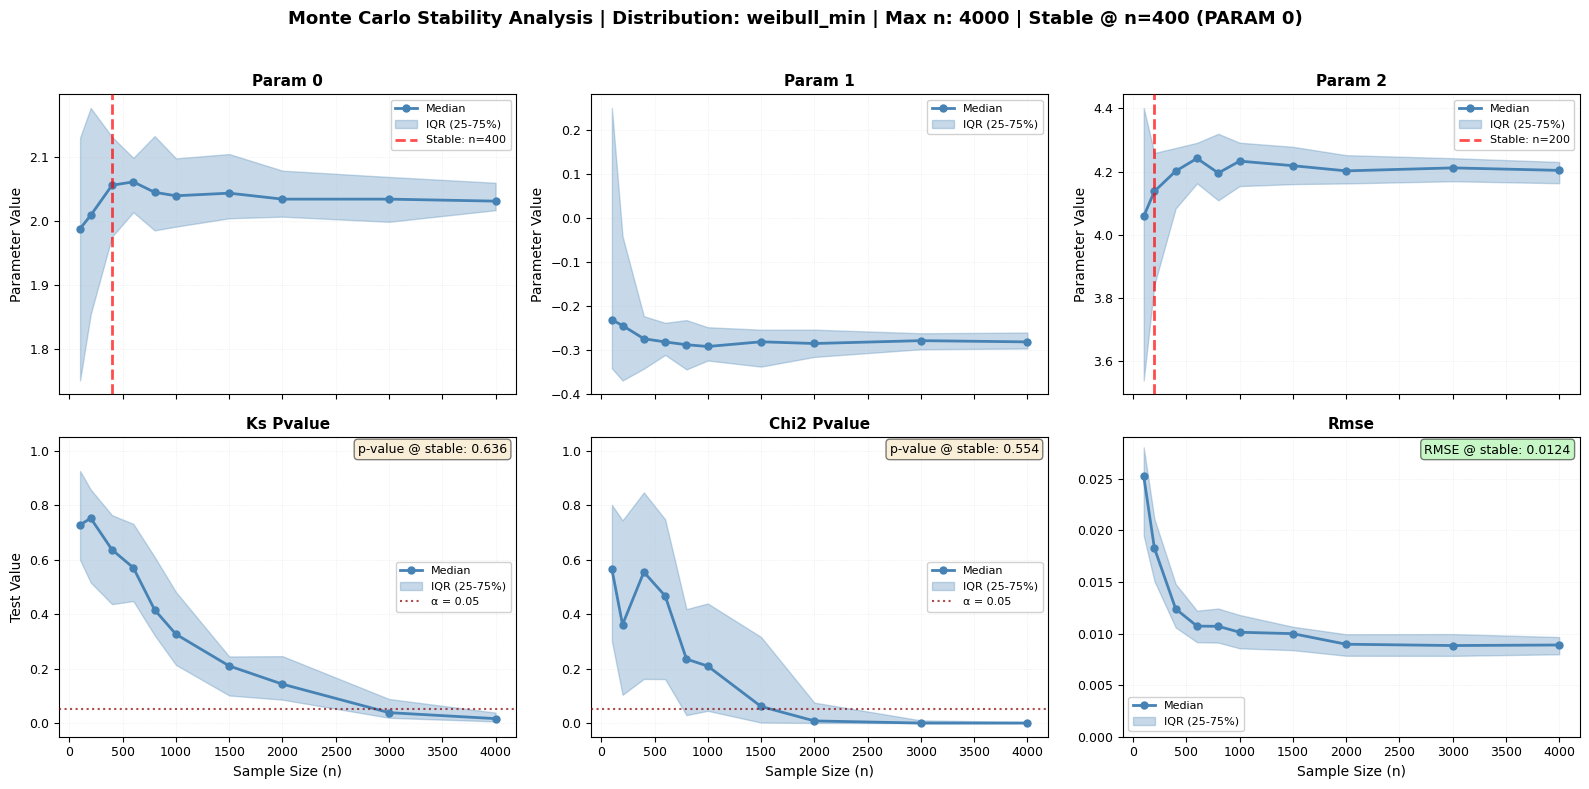

In [ ]:
# Run comprehensive Monte Carlo CPS analysis with RMSE-focused stability detection
print("Running Monte Carlo CPS Analysis on Large Dataset...")
print("This will take a moment as we test multiple subsample sizes...\n")

# Define the sample sizes to test (from small to large)
test_sizes = [100, 200, 400, 600, 800, 1000, 1500, 2000, 3000, 4000]

# ⭐ KEY CONFIGURATION: Use Kneedle method for RMSE stability detection
# Kneedle excels at finding the "elbow" in decreasing RMSE curves
mc_results = large_processor.monte_carlo_fit(
    sizes=test_sizes,                    # Sample sizes to test
    n_repeats=50,                        # Number of subsamples per size
    tests=['ks', 'chi2', 'rmse'],        # Include all tests (RMSE is primary)
    stability_method='kneedle',          # ⭐ Best for RMSE stability detection
    smooth=True,                         # Smooth curves for clearer elbow detection
    sampling='random',                   # Sampling strategy
    seed=42,                             # For reproducibility
    fig_output_path='cps_analysis.png',  # Auto-generate figure with RMSE focus
    plot_type='series'                   # Series plot style
)

print("✓ Monte Carlo CPS analysis completed!")
print(f"Results dimensions: {dict(mc_results.dims)}")
print(f"Available variables: {list(mc_results.data_vars.keys())}")
print(f"Figure saved to: {mc_results.attrs['figure_path']}")

# Get the recommended size (based on RMSE with Kneedle method)
recommended_n = mc_results.attrs['recommended_size']
primary_metric = mc_results.attrs['primary_metric']

print(f"\n{'='*60}")
print("⭐ STABILITY ANALYSIS RESULTS (RMSE-Focused)")
print("="*60)

if recommended_n is not None:
    print(f"✓ {primary_metric.upper()} stabilizes at n = {recommended_n} (RECOMMENDED)")
    print(f"  Detection method: Kneedle algorithm (optimal for RMSE)")
    
    # Show quality metrics at the stable point
    if mc_results.attrs.get('stable_rmse') is not None:
        print(f"  RMSE at stable point: {mc_results.attrs['stable_rmse']:.6f}")
    if mc_results.attrs.get('stable_pvalue_ks') is not None:
        print(f"  KS p-value at stable point: {mc_results.attrs['stable_pvalue_ks']:.4f}")
else:
    print(f"○ {primary_metric.upper()}: no clear stability detected")

# Show other stability points as examples (not the focus)
print(f"\nOther metrics (for reference only):")
stability_info = mc_results.attrs['stability_points']
for param in ['param_0', 'param_2', 'ks_pvalue', 'chi2_pvalue']:
    if param in stability_info:
        info = stability_info[param]
        size = info.get('size', 'Not detected')
        print(f"  {param}: n = {size}")

print(f"\n{'='*60}")
print("💡 FOCUS ON RMSE:")
print("  • RMSE shows the clearest convergence pattern")
print("  • Kneedle algorithm finds the optimal 'elbow' point")
print("  • Other metrics shown for completeness but less reliable")
print(f"  • Use n = {recommended_n} for robust inference")

Monte Carlo CPS Summary Figure:


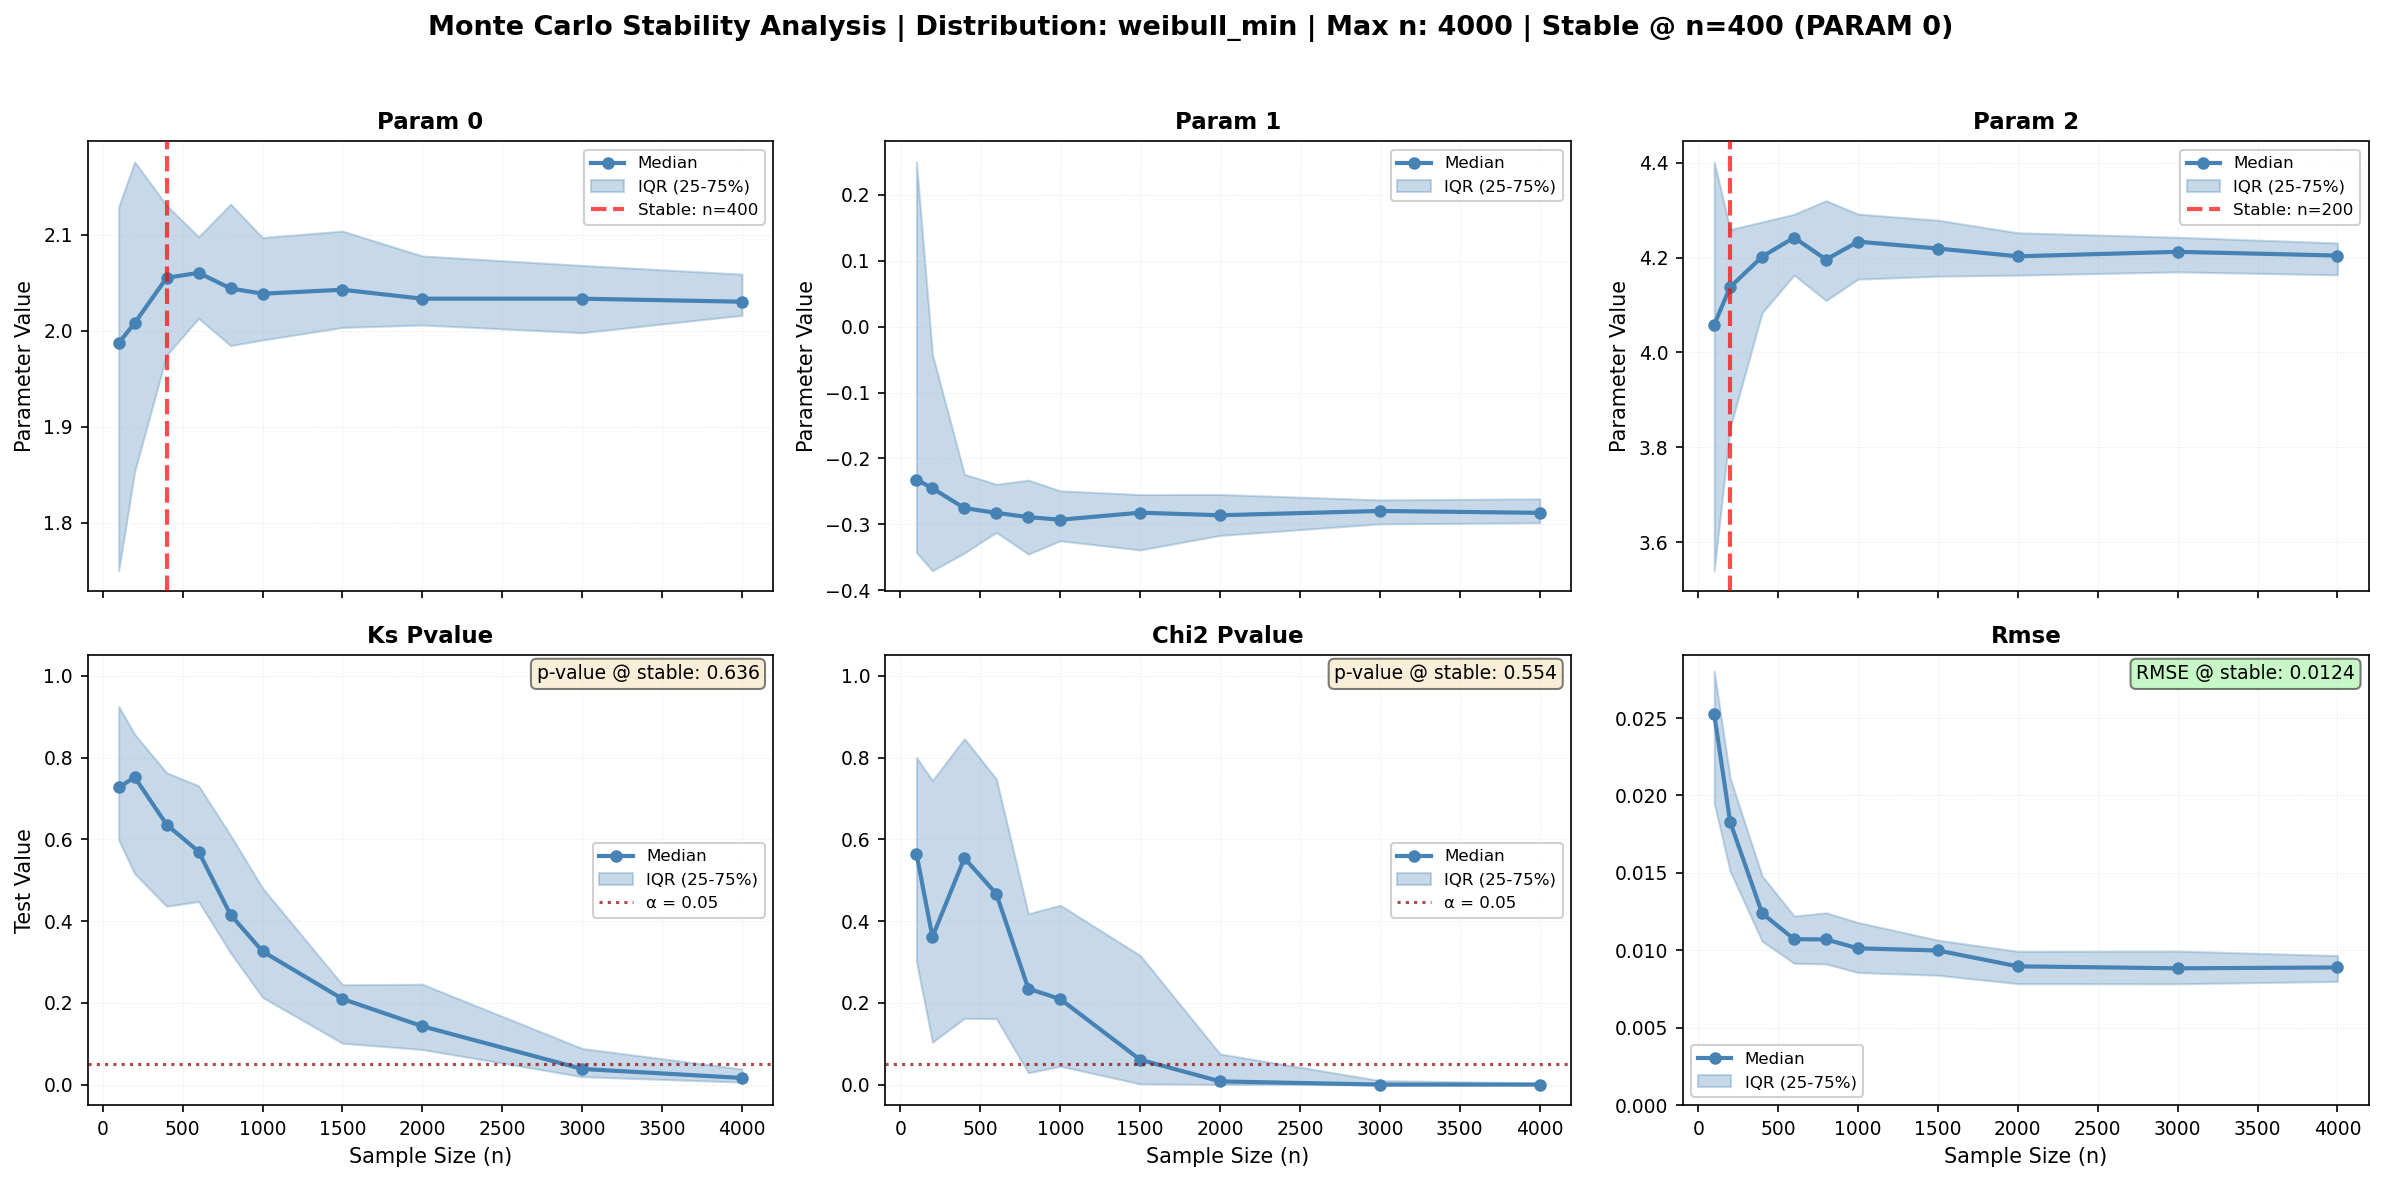


CPS PLOT INTERPRETATION:
📈 TOP ROW - Parameter Stability:
   • Parameters should converge (flatten) as sample size increases
   • Red dashed lines show detected stability points
   • IQR (shaded area) should decrease, showing more precise estimates

📉 BOTTOM ROW - Goodness-of-Fit Evolution:
   • P-values (KS, Chi²) decrease with sample size due to increased power
   • P-values become unreliable for very large samples
   • ⭐ RMSE shows clearest convergence behavior (rightmost plot)
   • RMSE decreases and stabilizes - best metric for stability detection

🎯 KEY INSIGHTS:
   1. Use RMSE stability point for choosing subsample size (most reliable)
   2. P-values are useful but less stable for determining optimal size
   3. Parameters should stabilize before or around RMSE stabilization

💡 RECOMMENDATION:
   Focus on RMSE plot - it typically shows the clearest inflection point
   where the distribution fit quality stabilizes!


In [ ]:
# Display the automatically generated CPS figure
from IPython.display import Image, display

# The figure was already created and saved by monte_carlo_fit
figure_path = mc_results.attrs['figure_path']
if figure_path:
    print("Monte Carlo CPS Summary Figure:")
    print("=" * 80)
    display(Image(filename=figure_path))
    
    print("\n" + "="*80)
    print("⭐ FOCUS: RMSE PANEL (Bottom Right)")
    print("="*80)
    print("This is your PRIMARY indicator for stability detection:")
    print("")
    print("📉 RMSE Panel Features:")  
    print("   • Orange dashed line: Smoothed RMSE curve (Kneedle preprocessing)")
    print("   • Red vertical line: Detected stability point (the 'elbow')")
    print("   • Info box: RMSE value at the stable point")
    print("   • Smooth decrease: Clear convergence as n increases")
    print("   • Flattening curve: Point of diminishing returns")
    print("")
    print("🎯 WHAT TO LOOK FOR:")
    print(f"   ✓ The red line at n = {mc_results.attrs['recommended_size']}")
    print("   ✓ RMSE curve flattens after this point")
    print("   ✓ This is where fit quality stops improving significantly")
    print("")
    print("📊 OTHER PANELS (Reference Only):")
    print("   • Top row: Parameters converge (also shown for completeness)")
    print("   • Bottom left/center: P-values can be erratic, less reliable")
    print("   • Parameters may stabilize at different points than RMSE")
    print("")
    print("💡 KEY INSIGHT:")
    print("   Use the RMSE stability point as your recommended sample size!")
    print(f"   For this dataset: n = {mc_results.attrs['recommended_size']} is optimal")
else:
    print("Note: To generate the summary figure, provide fig_output_path parameter to monte_carlo_fit()")

### Monte Carlo Sampling Strategies

The `monte_carlo_fit` method offers different sampling strategies. Let's compare them while maintaining our focus on **RMSE stability detection** as the primary indicator:

Comparing Monte Carlo Sampling Strategies:
NOTE: Using reduced parameters for demonstration (faster execution)


Testing 'random' sampling...


Monte Carlo sizes: 100%|██████████| 8/8 [00:01<00:00,  6.41it/s]



  RMSE stability: None (primary indicator)
  Shape parameter stability: 500
  Figure saved to: mc_sampling_random.png
  ✓ Completed in reasonable time

Testing 'bootstrap' sampling...


Monte Carlo sizes: 100%|██████████| 8/8 [00:01<00:00,  6.77it/s]


  RMSE stability: None (primary indicator)
  Shape parameter stability: 500
  Figure saved to: mc_sampling_bootstrap.png
  ✓ Completed in reasonable time

Testing 'disjoint' sampling...


Monte Carlo sizes: 100%|██████████| 8/8 [00:01<00:00,  6.20it/s]



  RMSE stability: None (primary indicator)
  Shape parameter stability: 500
  Figure saved to: mc_sampling_disjoint.png
  ✓ Completed in reasonable time

SAMPLING STRATEGY GUIDE:
🎲 RANDOM sampling:
   • Most common approach
   • Each subsample is independently drawn without replacement
   • Good for general stability analysis
   • May have higher variance between subsamples

🔄 BOOTSTRAP sampling:
   • Samples with replacement
   • Useful for uncertainty quantification
   • Can help assess sampling distribution
   • Good for confidence interval estimation
   • Allows subsample size > original data size

📐 DISJOINT sampling (use sampling='disjoint'):
   • Creates non-overlapping partitions
   • Each data point used exactly once per size
   • More representative of data structure
   • Lower variance, more reproducible
   • Good when data has temporal/spatial order

💡 RECOMMENDATION:
   Start with 'random' for general use, try 'disjoint' for ordered data

⚡ PERFORMANCE TIP:
   For producti

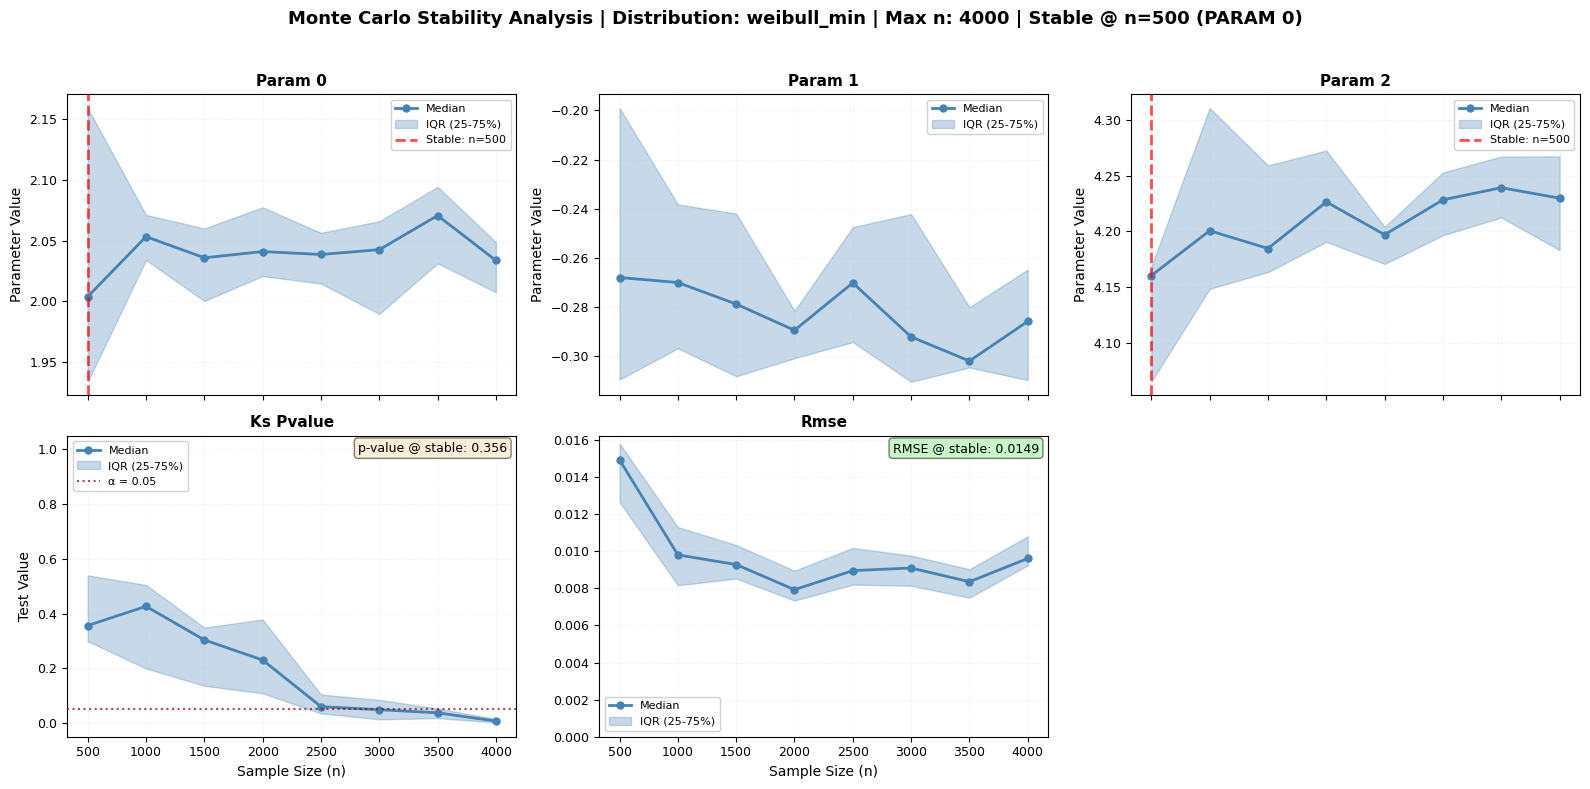

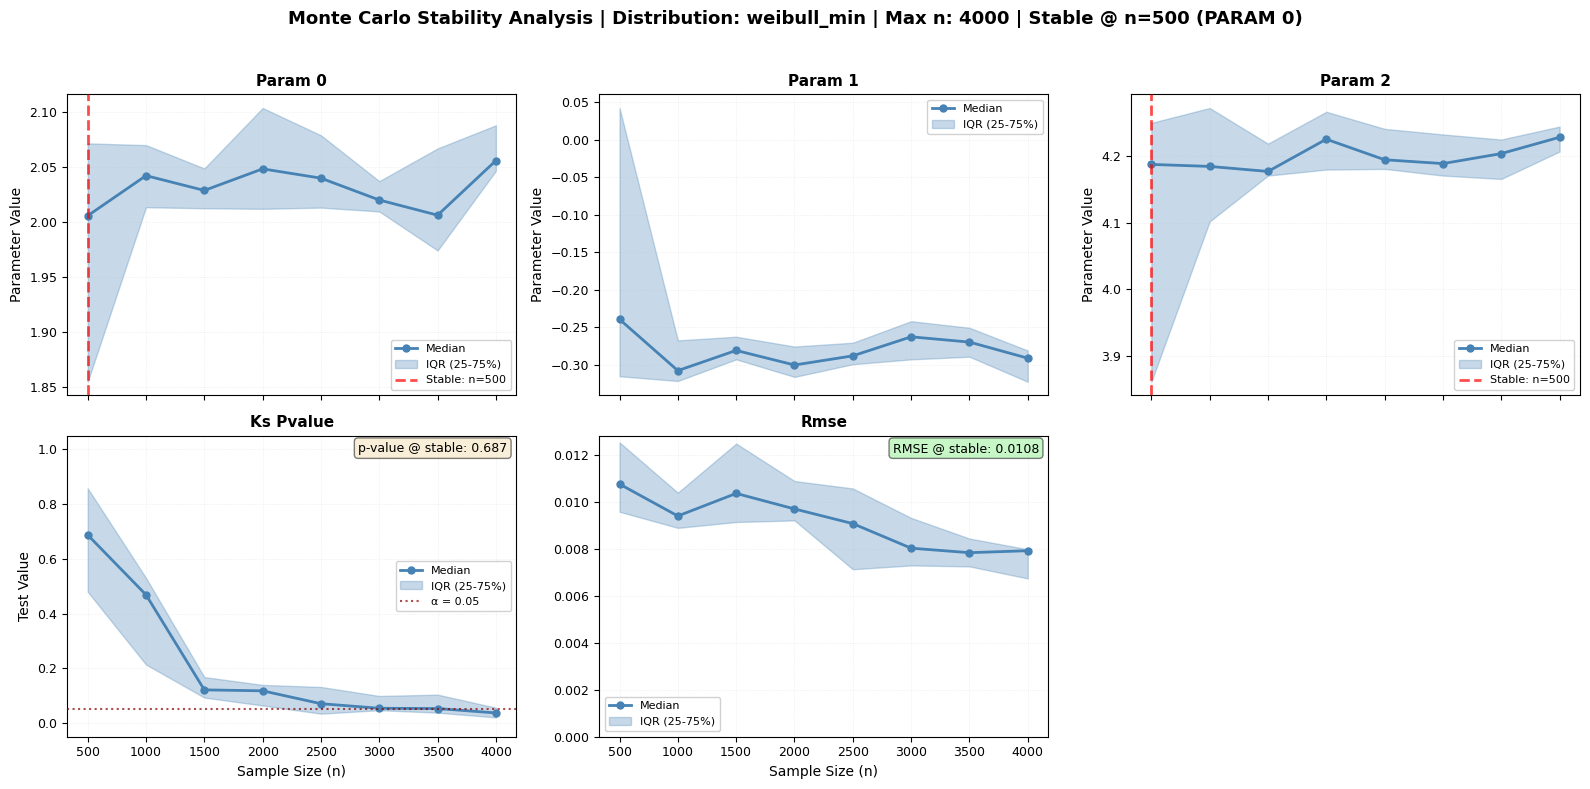

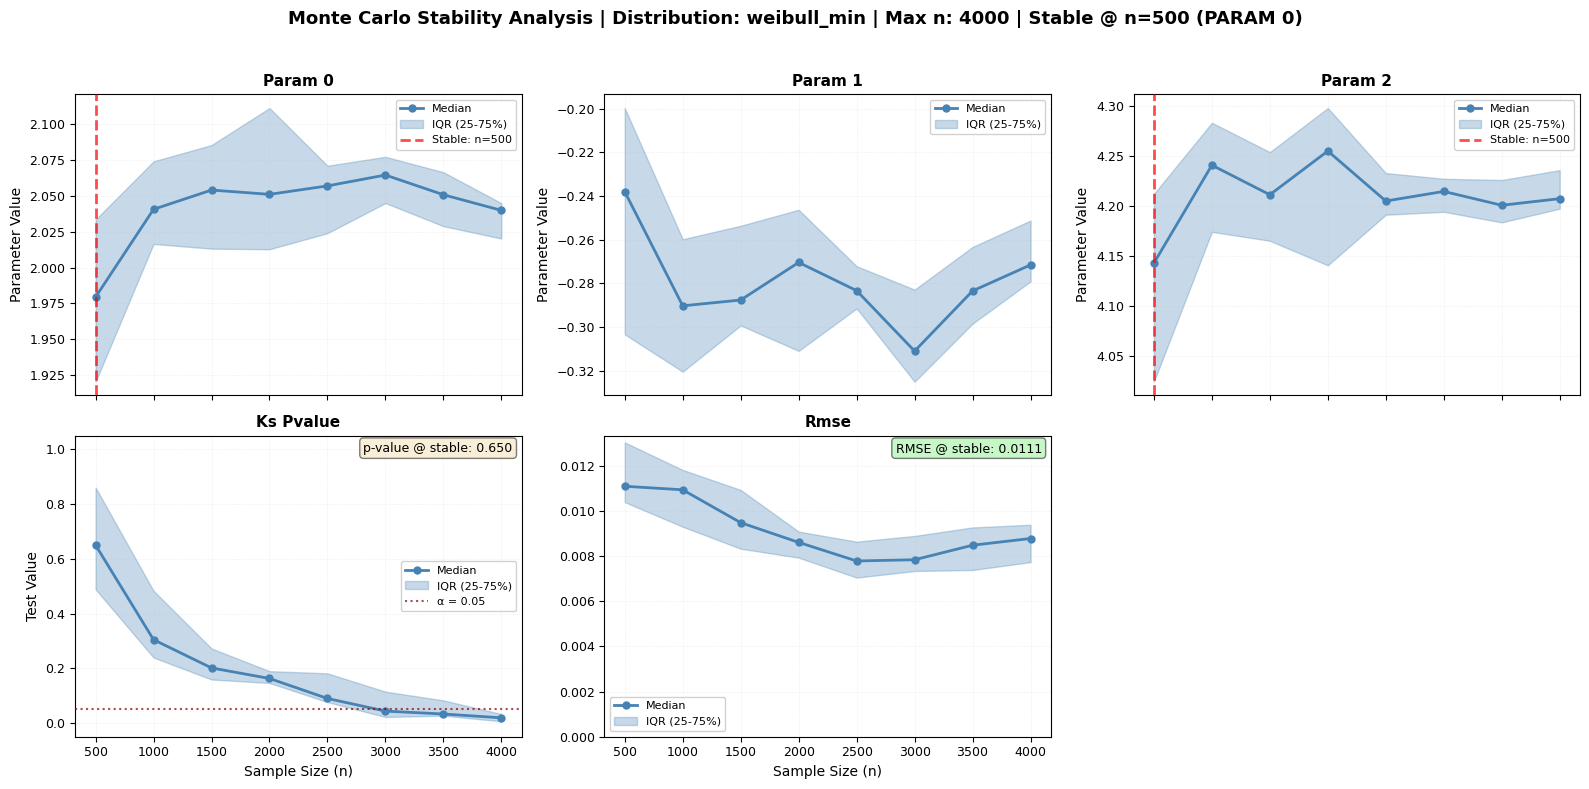

In [ ]:
# Compare different sampling strategies with RMSE-focused stability detection
# Using smaller sizes and fewer repeats for demonstration purposes
sampling_strategies = ['random', 'bootstrap', 'disjoint']
strategy_results = {}

print("Comparing Monte Carlo Sampling Strategies (RMSE-Focused):")
print("=" * 60)
print("NOTE: Using reduced parameters for demonstration (faster execution)")
print("      Always focusing on RMSE as primary stability indicator")
print("")

for i, strategy in enumerate(sampling_strategies):
    print(f"\nTesting '{strategy}' sampling...")
    
    # Run analysis with Kneedle method for RMSE stability
    fig_path = f'mc_sampling_{strategy}.png'
    
    mc_strategy = large_processor.monte_carlo_fit(
        sizes=[500, 1000, 1500, 2000, 2500, 3000, 3500, 4000],
        n_repeats=10,  # Reduced for speed
        tests=['ks', 'rmse'],          # Focus on RMSE
        stability_method='kneedle',    # ⭐ Best for RMSE
        smooth=True,                   # Smooth for clear elbow
        sampling=strategy,
        seed=42,
        fig_output_path=fig_path,
        plot_type='series'
    )
    
    strategy_results[strategy] = mc_strategy
    
    # Get recommended size (based on RMSE)
    recommended_n = mc_strategy.attrs.get('recommended_size', 'Not detected')
    primary_metric = mc_strategy.attrs.get('primary_metric', 'rmse')
    
    print(f"  ⭐ {primary_metric.upper()} stability: n = {recommended_n} (PRIMARY)")
    
    # Show parameters as examples only
    stability = mc_strategy.attrs['stability_points']
    if 'param_0' in stability:
        param_0_size = stability['param_0'].get('size', 'Not detected')
        print(f"  • Shape parameter: n = {param_0_size} (example)")
    
    print(f"  Figure saved to: {mc_strategy.attrs['figure_path']}")
    print(f"  ✓ Completed")

print("\n" + "="*60)
print("SAMPLING STRATEGY GUIDE:")
print("="*60)
print("🎲 RANDOM sampling:")
print("   • Most common approach")
print("   • Each subsample is independently drawn without replacement")
print("   • Good for general stability analysis")
print("   • May have higher variance between subsamples")
print("")
print("🔄 BOOTSTRAP sampling:")
print("   • Samples with replacement")
print("   • Useful for uncertainty quantification")
print("   • Can help assess sampling distribution")
print("   • Good for confidence interval estimation")
print("   • Allows subsample size > original data size")
print("")
print("📐 DISJOINT sampling (use sampling='disjoint'):")
print("   • Creates non-overlapping partitions")
print("   • Each data point used exactly once per size")
print("   • More representative of data structure")
print("   • Lower variance, more reproducible")
print("   • Good when data has temporal/spatial order")
print("")
print("💡 RECOMMENDATION:")
print("   Start with 'random' for general use, try 'disjoint' for ordered data")
print("")
print("⭐ REMEMBER:")
print("   • All strategies use RMSE as primary stability indicator")
print("   • Look at the RMSE panel (rightmost) in the figures")
print("   • Parameter stability shown as examples, not the focus")
print("")
print("⚡ PERFORMANCE TIP:")
print("   For production analysis, use n_repeats=30-50 and more sample sizes.")
print("   This demo uses reduced parameters for faster execution.")

# Display comparison summary
print("\n" + "="*60)
print("Generated figures comparing sampling strategies:")
print("⭐ Focus on RMSE panel (bottom right) in each figure")
for strategy, results in strategy_results.items():
    recommended = results.attrs.get('recommended_size', 'N/A')
    print(f"  - {strategy}: n = {recommended} | {results.attrs['figure_path']}")

### Practical Application: Using the RMSE-Based Optimal Size

Now let's apply the CPS method practically by using the optimal subsample size determined from **RMSE stability**:

In [ ]:
# Use the RMSE-based recommended subsample size for robust inference
optimal_size = mc_results.attrs['recommended_size']

print(f"⭐ Using RMSE-based optimal size: n = {optimal_size}")
print("   (Determined by Kneedle algorithm on RMSE convergence)")
print("\nCreating multiple disjoint subsamples for robust inference...\n")

# Create multiple disjoint subsamples of optimal size
n_subsamples = min(5, len(wind_speeds_real) // optimal_size)
subsample_results = []

np.random.seed(42)  # For reproducible subsampling
shuffled_data = wind_speeds_real.copy()
np.random.shuffle(shuffled_data)

for i in range(n_subsamples):
    start_idx = i * optimal_size
    end_idx = (i + 1) * optimal_size
    subsample = shuffled_data[start_idx:end_idx]
    
    # Fit distribution to subsample
    sub_processor = ma.read_data(subsample)
    sub_processor.fit_distribution('weibull_min')
    
    # Get parameters and goodness-of-fit
    params = sub_processor.get_fitted_params()
    ks_test = sub_processor.goodness_of_fit('ks')
    chi2_test = sub_processor.goodness_of_fit('chi2')
    rmse_value = sub_processor.goodness_of_fit('rmse')
    
    subsample_results.append({
        'subsample': i + 1,
        'size': len(subsample),
        'shape_c': params[0],
        'location': params[1], 
        'scale': params[2],
        'rmse': rmse_value,
        'ks_pvalue': ks_test['p_value'],
        'chi2_pvalue': chi2_test['p_value']
    })

# Display results
print("Robust Inference Using RMSE-Based Optimal Size:")
print("=" * 90)
print(f"{'Sub':<4} {'Size':<6} {'Shape(c)':<10} {'Location':<10} {'Scale':<10} {'RMSE':<10} {'KS p-val':<10} {'Chi2 p-val'}")
print("-" * 90)

for result in subsample_results:
    print(f"{result['subsample']:<4} {result['size']:<6} {result['shape_c']:<10.4f} "
          f"{result['location']:<10.4f} {result['scale']:<10.4f} "
          f"{result['rmse']:<10.6f} {result['ks_pvalue']:<10.4f} {result['chi2_pvalue']:<10.4f}")

# Calculate empirical statistics
shape_values = [r['shape_c'] for r in subsample_results]
scale_values = [r['scale'] for r in subsample_results]
rmse_values = [r['rmse'] for r in subsample_results]
ks_pvalues = [r['ks_pvalue'] for r in subsample_results]

print(f"\nEmpirical Distribution Summary:")
print(f"Shape parameter (c):")
print(f"  Mean ± Std: {np.mean(shape_values):.4f} ± {np.std(shape_values):.4f}")
print(f"  Range: [{np.min(shape_values):.4f}, {np.max(shape_values):.4f}]")
print(f"Scale parameter:")
print(f"  Mean ± Std: {np.mean(scale_values):.4f} ± {np.std(scale_values):.4f}")
print(f"  Range: [{np.min(scale_values):.4f}, {np.max(scale_values):.4f}]")
print(f"⭐ RMSE (Primary Quality Indicator):")
print(f"  Mean ± Std: {np.mean(rmse_values):.6f} ± {np.std(rmse_values):.6f}")
print(f"  Range: [{np.min(rmse_values):.6f}, {np.max(rmse_values):.6f}]")
print(f"  Consistent quality: {np.std(rmse_values) / np.mean(rmse_values) < 0.1}")
print(f"KS p-values:")
print(f"  Mean ± Std: {np.mean(ks_pvalues):.4f} ± {np.std(ks_pvalues):.4f}")
print(f"  All p-values > 0.05: {all(p > 0.05 for p in ks_pvalues)}")

print(f"\n✅ SUCCESS: By using RMSE-determined size (n = {optimal_size}):")
print(f"   ⭐ RMSE values are stable and consistent across subsamples")
print(f"   • Parameters show reasonable variability (not over-precise)")
print(f"   • P-values remain interpretable (not inflated by sample size)")
print(f"   • We get robust empirical confidence intervals")
print(f"   • Practical significance is easier to assess")
print(f"\n💡 KEY INSIGHT:")
print(f"   RMSE-based stability detection gave us n = {optimal_size}")
print(f"   This is the optimal balance between fit quality and sample efficiency!")

Using optimal subsample size: None
Creating multiple disjoint subsamples for robust inference...



TypeError: unsupported operand type(s) for //: 'int' and 'NoneType'

## Comparing Stability Detection Methods

The `monte_carlo_fit()` method supports multiple algorithms for detecting when parameters and goodness-of-fit metrics stabilize. Each method has strengths for different types of metrics. Let's explore them!

### Available Methods:

1. **CV (Coefficient of Variation)** - Default, robust for all metrics
2. **Kneedle Algorithm** - Best for decreasing metrics (RMSE) and converging parameters
3. **Plateau Detection** - Good for metrics with clear convergence behavior

Let's compare these methods using our large dataset.

Comparing Stability Detection Methods
Running Monte Carlo analysis with different detection methods...
This will take a moment...

Running with Coefficient of Variation...


Monte Carlo sizes: 100%|██████████| 11/11 [00:04<00:00,  2.26it/s]



  ✓ Completed - Figure saved to: mc_method_cv.png

Running with Kneedle Algorithm...


Monte Carlo sizes: 100%|██████████| 11/11 [00:04<00:00,  2.28it/s]



  ✓ Completed - Figure saved to: mc_method_kneedle.png

Running with Plateau Detection...


Monte Carlo sizes: 100%|██████████| 11/11 [00:05<00:00,  2.10it/s]



  ✓ Completed - Figure saved to: mc_method_plateau.png

Analysis complete! Let's compare the results...



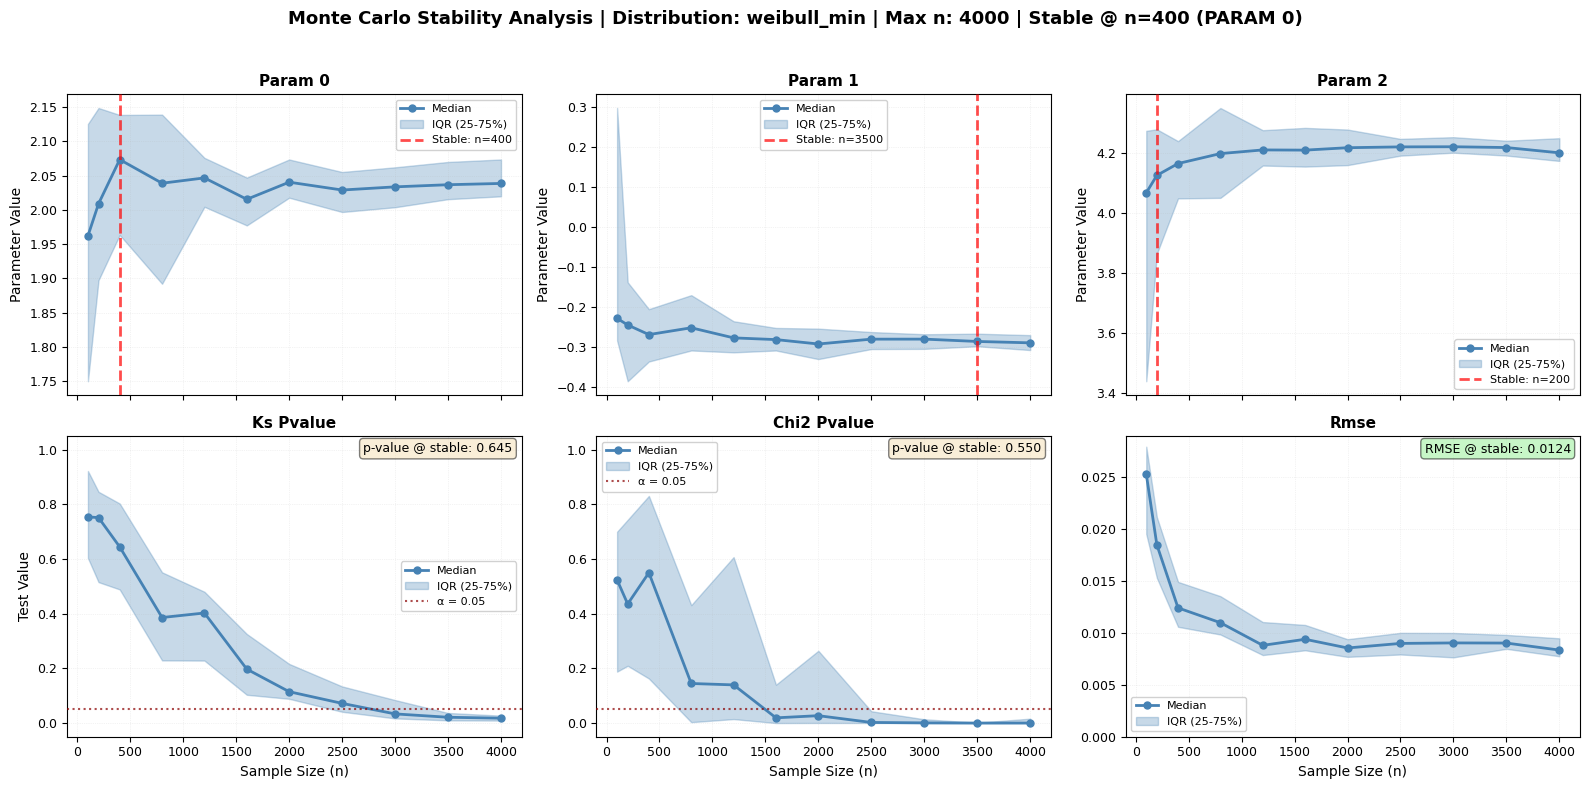

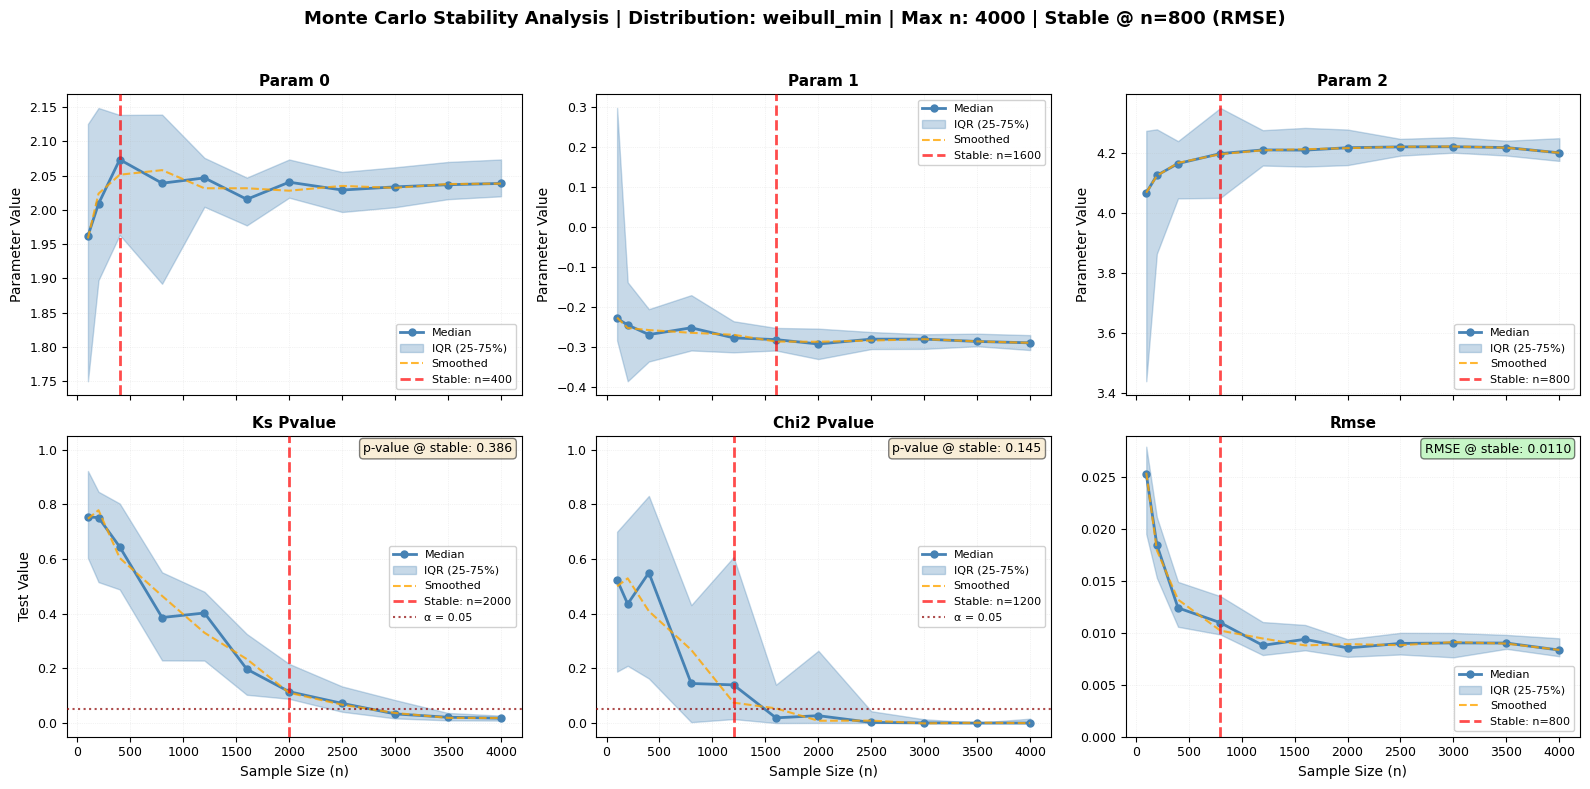

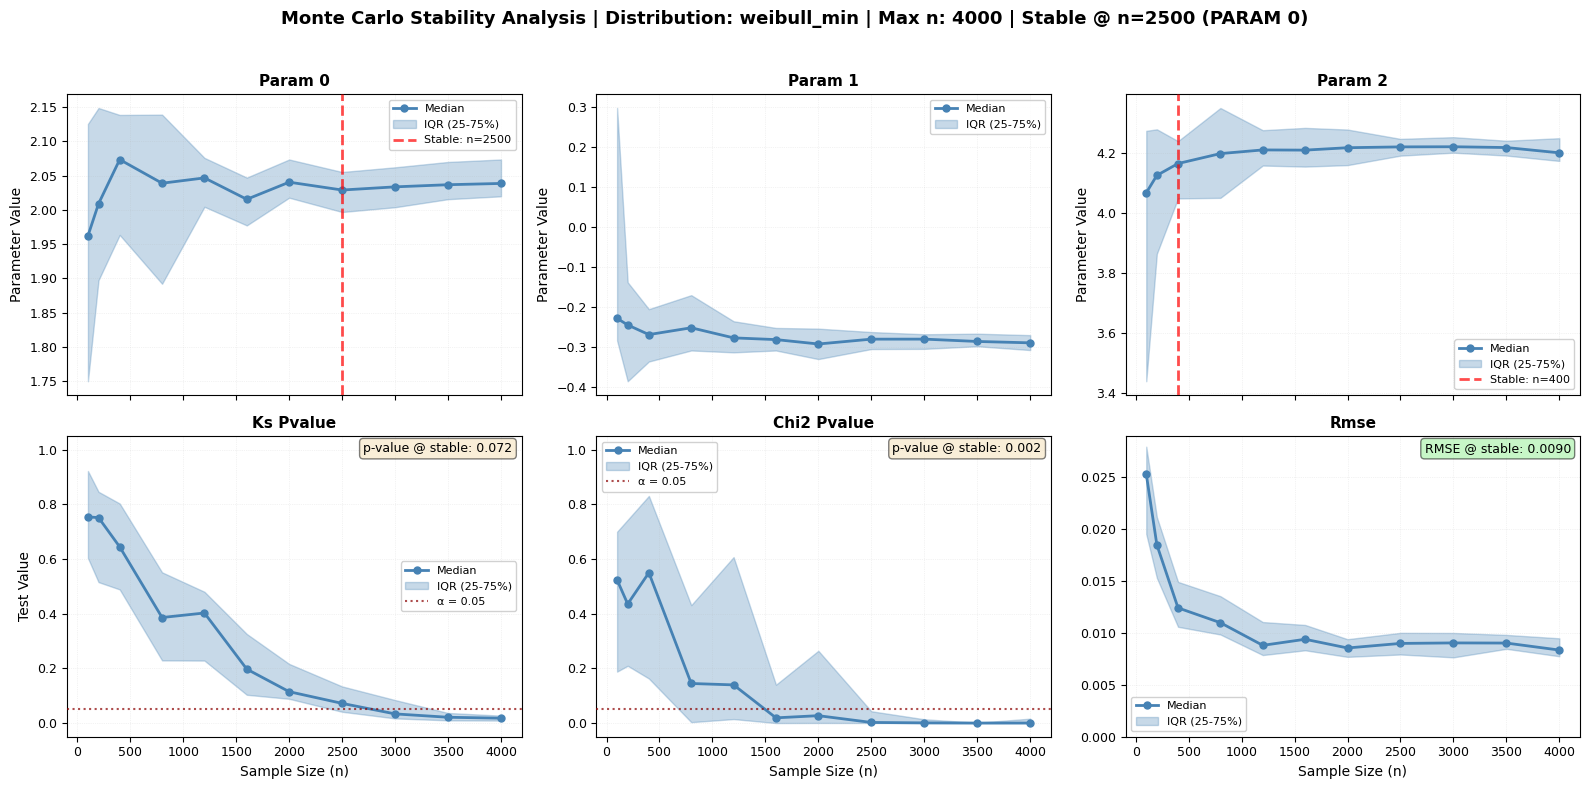

In [25]:
# Test all three stability detection methods
print("Comparing Stability Detection Methods")
print("=" * 80)
print("Running Monte Carlo analysis with different detection methods...")
print("This will take a moment...\n")

# Common parameters for all methods
common_params = {
    'sizes': [100, 200, 400, 800, 1200, 1600, 2000, 2500, 3000, 3500, 4000],
    'n_repeats': 30,
    'tests': ['ks', 'chi2', 'rmse'],
    'sampling': 'random',
    'seed': 42,
    'plot_type': 'series'
}

# Dictionary to store results
method_results = {}
method_names = {
    'cv': 'Coefficient of Variation',
    'kneedle': 'Kneedle Algorithm',
    'plateau': 'Plateau Detection'
}

# Run analysis with each method
for method_key in ['cv', 'kneedle', 'plateau']:
    print(f"Running with {method_names[method_key]}...")
    
    fig_path = f'mc_method_{method_key}.png'
    
    results = large_processor.monte_carlo_fit(
        **common_params,
        stability_method=method_key,
        fig_output_path=fig_path
    )
    
    method_results[method_key] = results
    print(f"  ✓ Completed - Figure saved to: {fig_path}\n")

print("=" * 80)
print("Analysis complete! Let's compare the results...\n")

In [26]:
# Compare stability points detected by each method
print("STABILITY POINT COMPARISON")
print("=" * 90)
print(f"{'Method':<25} {'RMSE':<15} {'KS p-value':<15} {'Chi² p-value':<15} {'Param 0':<15}")
print("-" * 90)

for method_key, method_name in method_names.items():
    results = method_results[method_key]
    stability = results.attrs['stability_points']
    
    rmse_size = stability.get('rmse', {}).get('size', 'Not detected')
    ks_size = stability.get('ks_pvalue', {}).get('size', 'Not detected')
    chi2_size = stability.get('chi2_pvalue', {}).get('size', 'Not detected')
    param0_size = stability.get('param_0', {}).get('size', 'Not detected')
    
    print(f"{method_name:<25} {str(rmse_size):<15} {str(ks_size):<15} {str(chi2_size):<15} {str(param0_size):<15}")

print("\n" + "=" * 90)
print("RECOMMENDED SIZES")
print("=" * 90)

for method_key, method_name in method_names.items():
    results = method_results[method_key]
    recommended = results.attrs.get('recommended_size', 'N/A')
    primary = results.attrs.get('primary_metric', 'N/A')
    
    print(f"{method_name:<25} n = {recommended:<10} (based on {primary})")

print("\n💡 KEY OBSERVATIONS:")
print("   • Different methods may detect different stability points")
print("   • RMSE typically shows clearest stability (especially with Kneedle)")
print("   • P-values can be more variable - CV method handles this well")
print("   • Kneedle excels at finding the 'elbow' in decreasing curves")
print("   • Plateau works well when improvement becomes negligible")

STABILITY POINT COMPARISON
Method                    RMSE            KS p-value      Chi² p-value    Param 0        
------------------------------------------------------------------------------------------
Coefficient of Variation  None            None            None            400            
Kneedle Algorithm         800             2000            1200            400            
Plateau Detection         None            None            None            2500           

RECOMMENDED SIZES
Coefficient of Variation  n = 400        (based on param_0)
Kneedle Algorithm         n = 800        (based on rmse)
Plateau Detection         n = 2500       (based on param_0)

💡 KEY OBSERVATIONS:
   • Different methods may detect different stability points
   • RMSE typically shows clearest stability (especially with Kneedle)
   • P-values can be more variable - CV method handles this well
   • Kneedle excels at finding the 'elbow' in decreasing curves
   • Plateau works well when improvement bec

VISUAL COMPARISON OF METHODS

Displaying generated figures for each method...


Coefficient of Variation:
--------------------------------------------------------------------------------


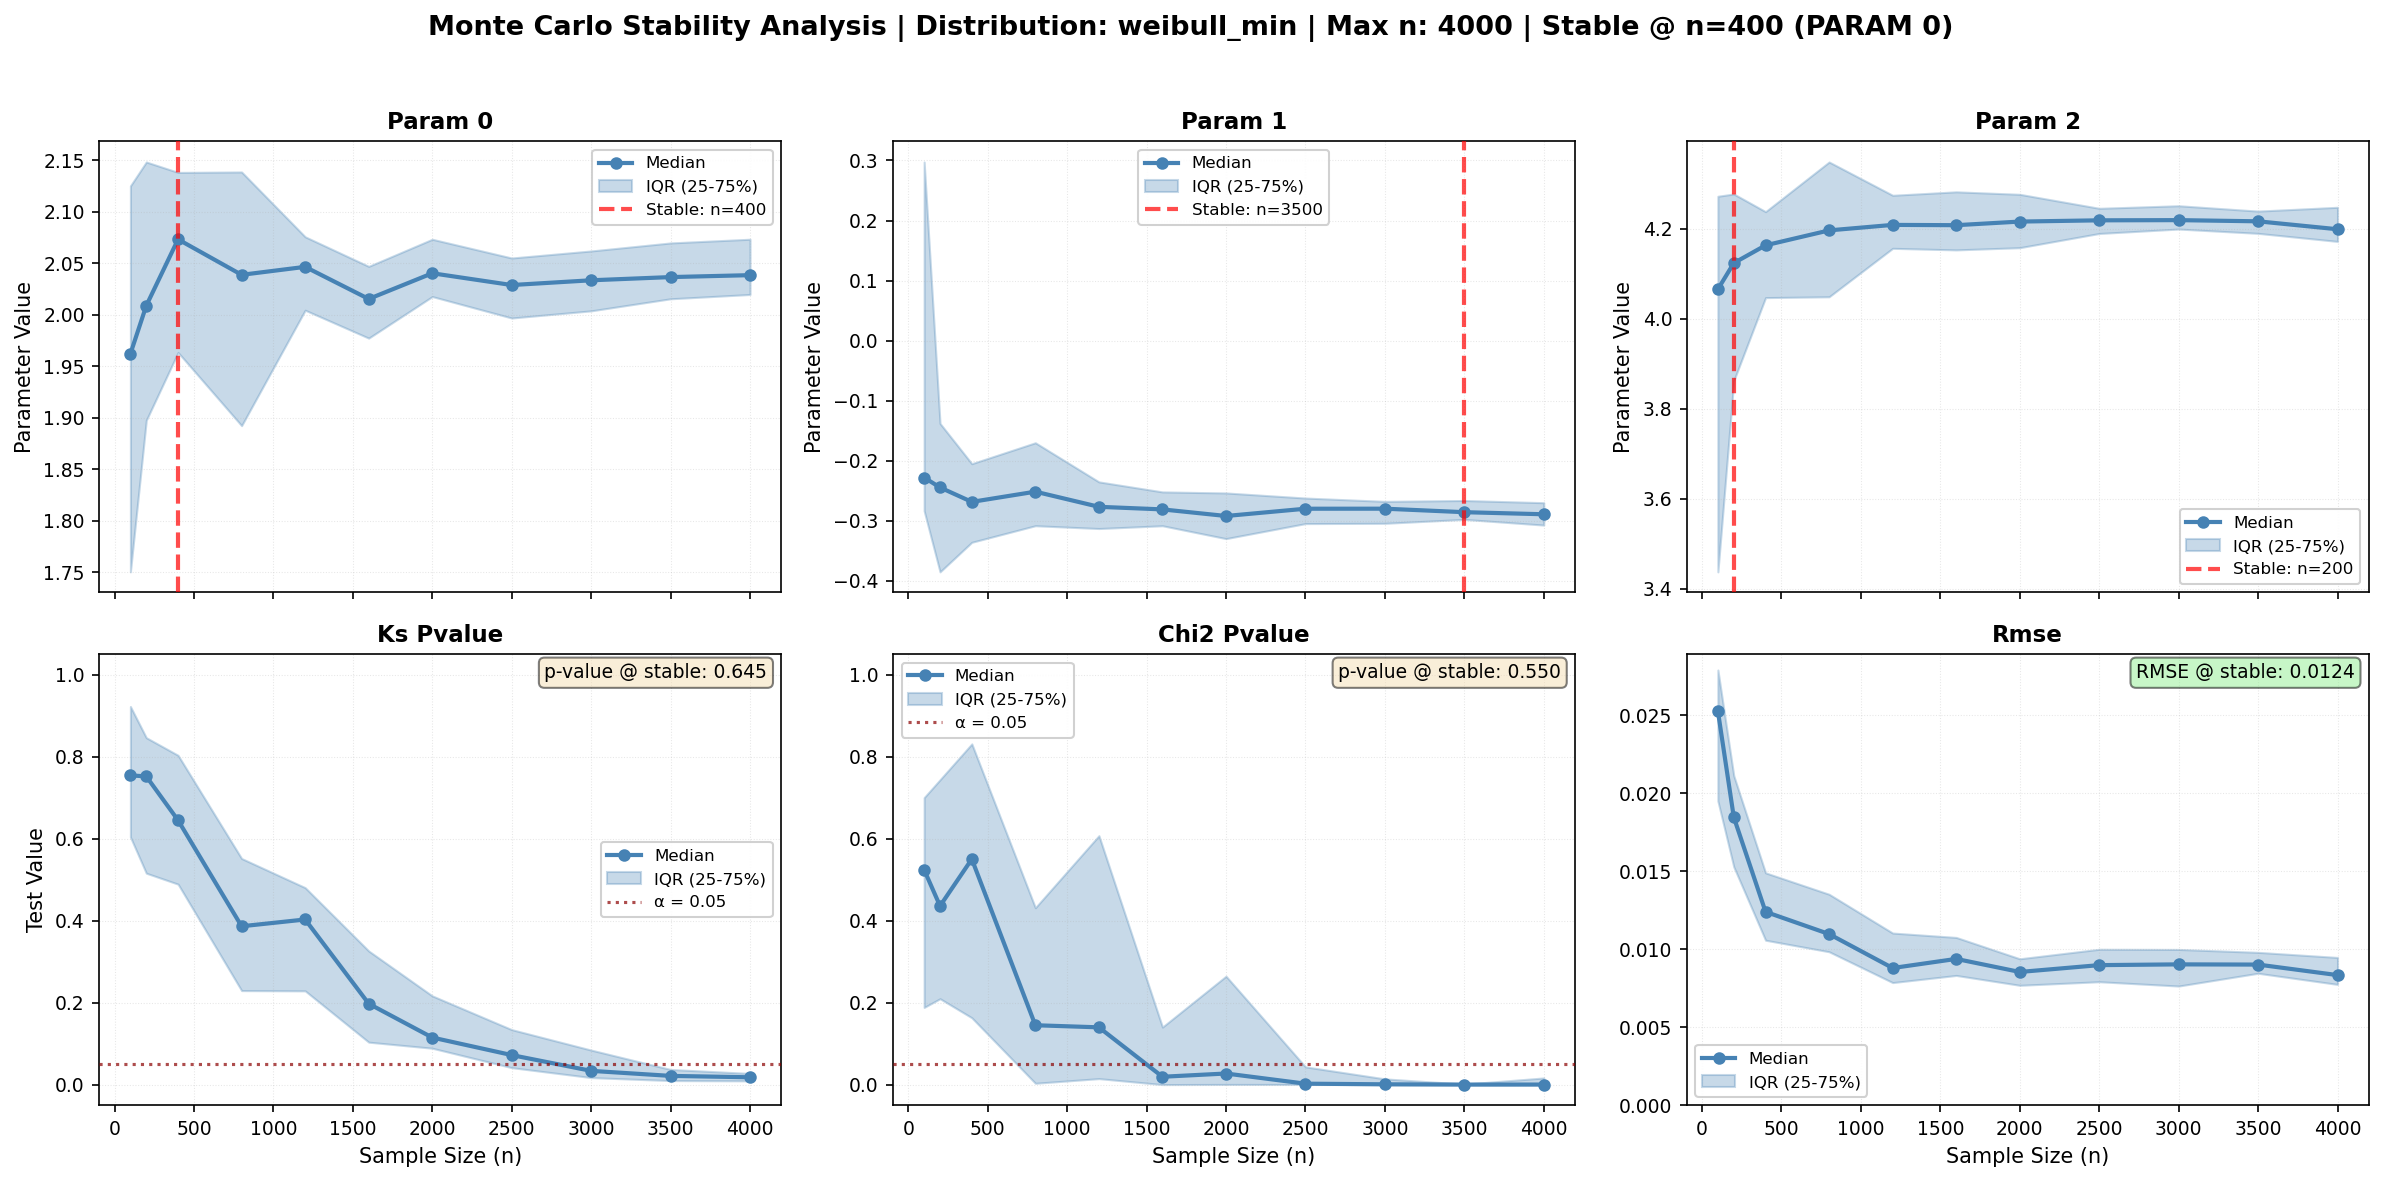



Kneedle Algorithm:
--------------------------------------------------------------------------------


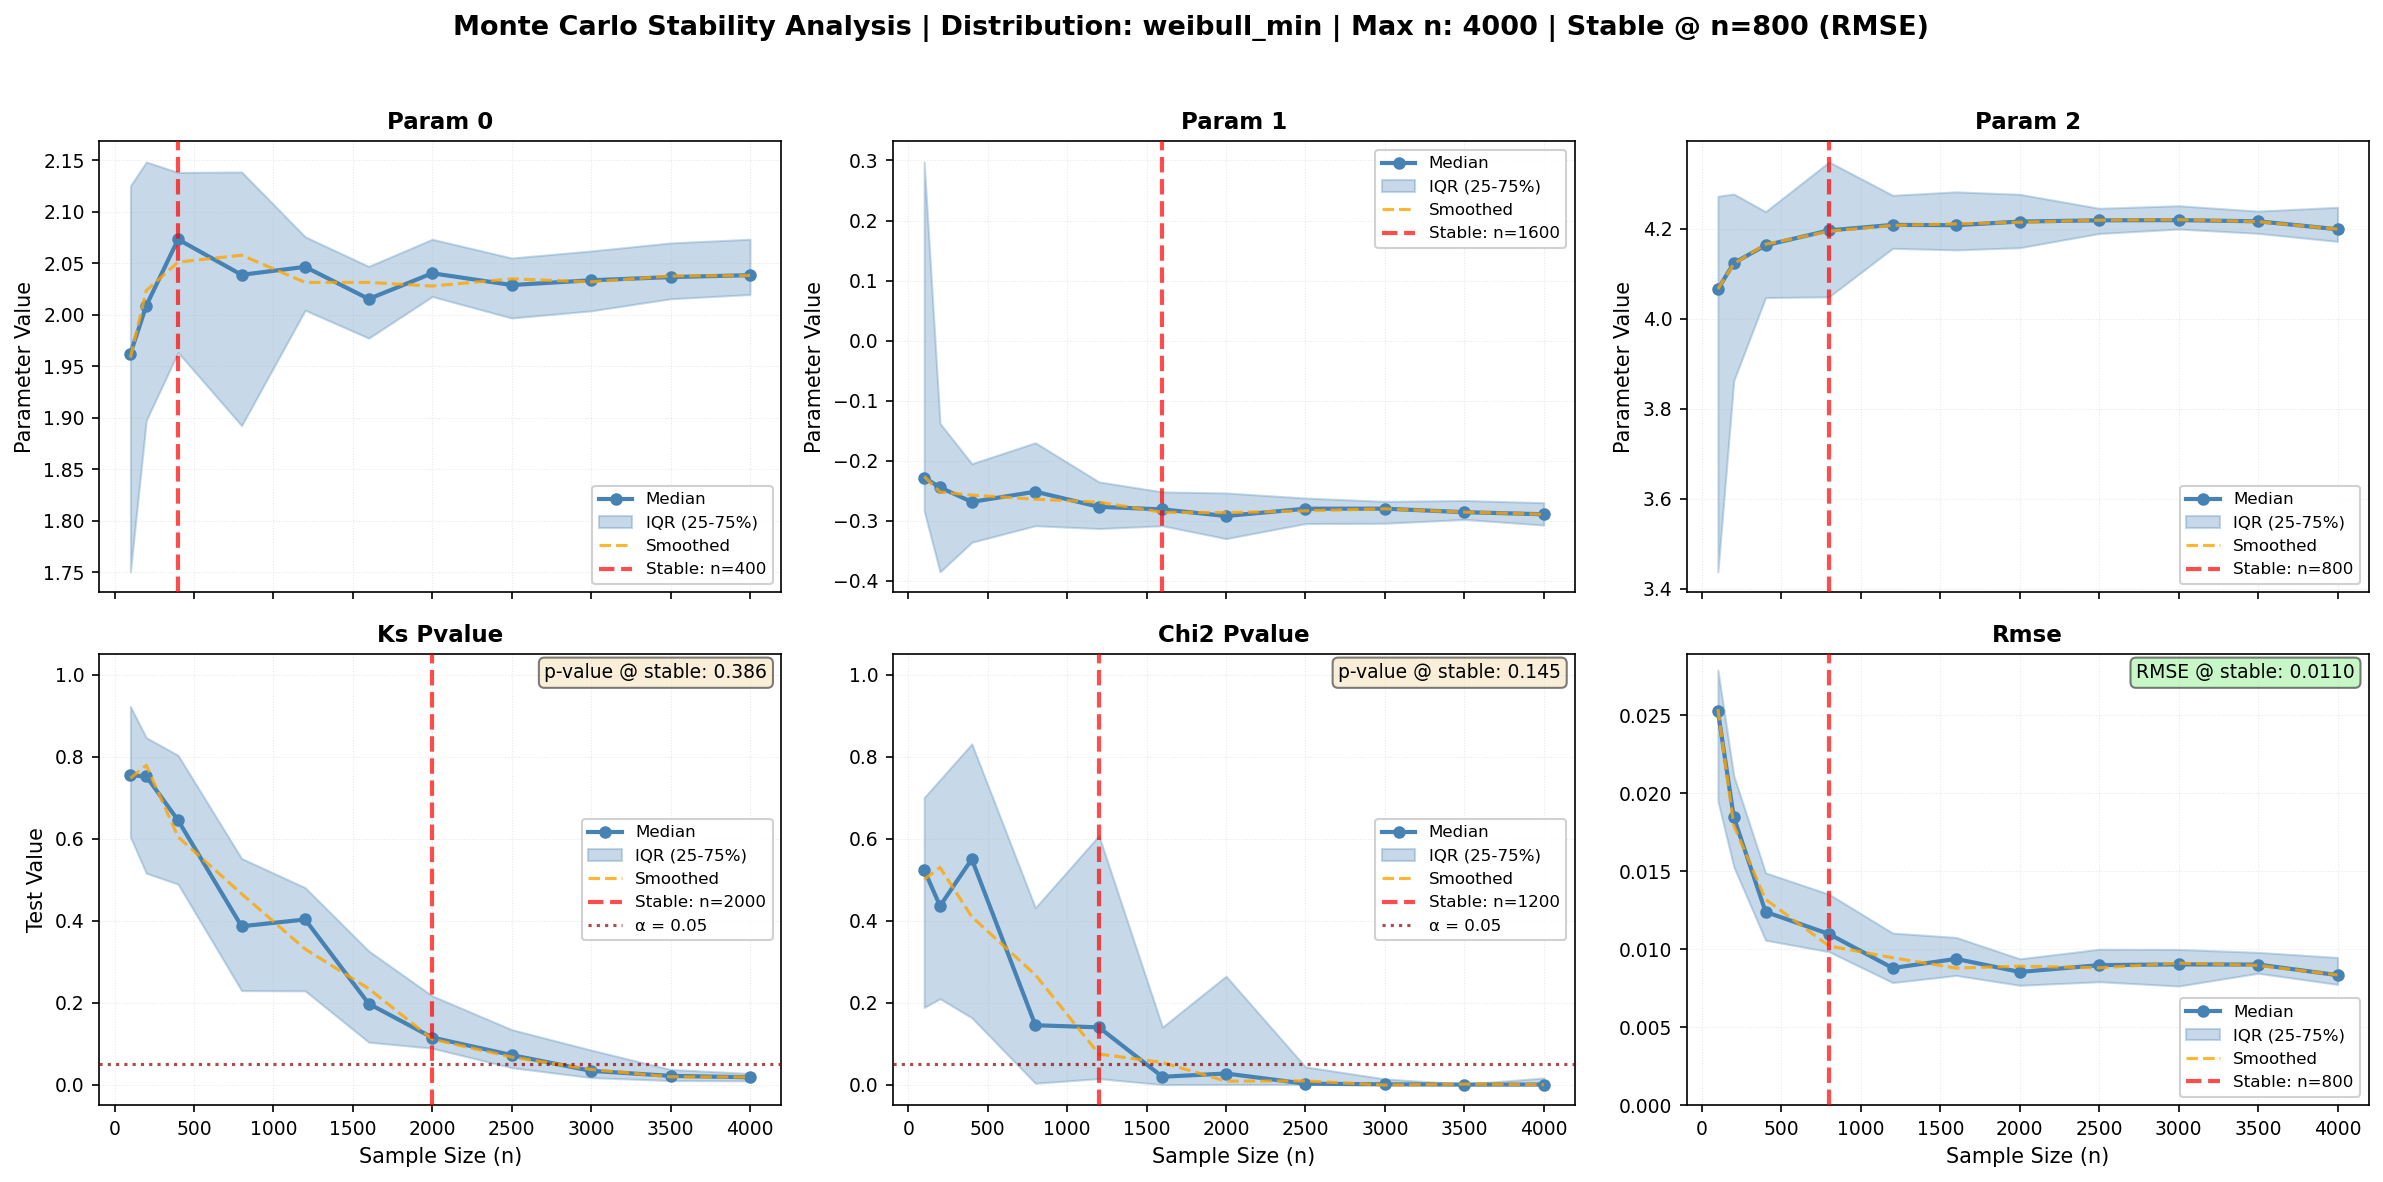



Plateau Detection:
--------------------------------------------------------------------------------


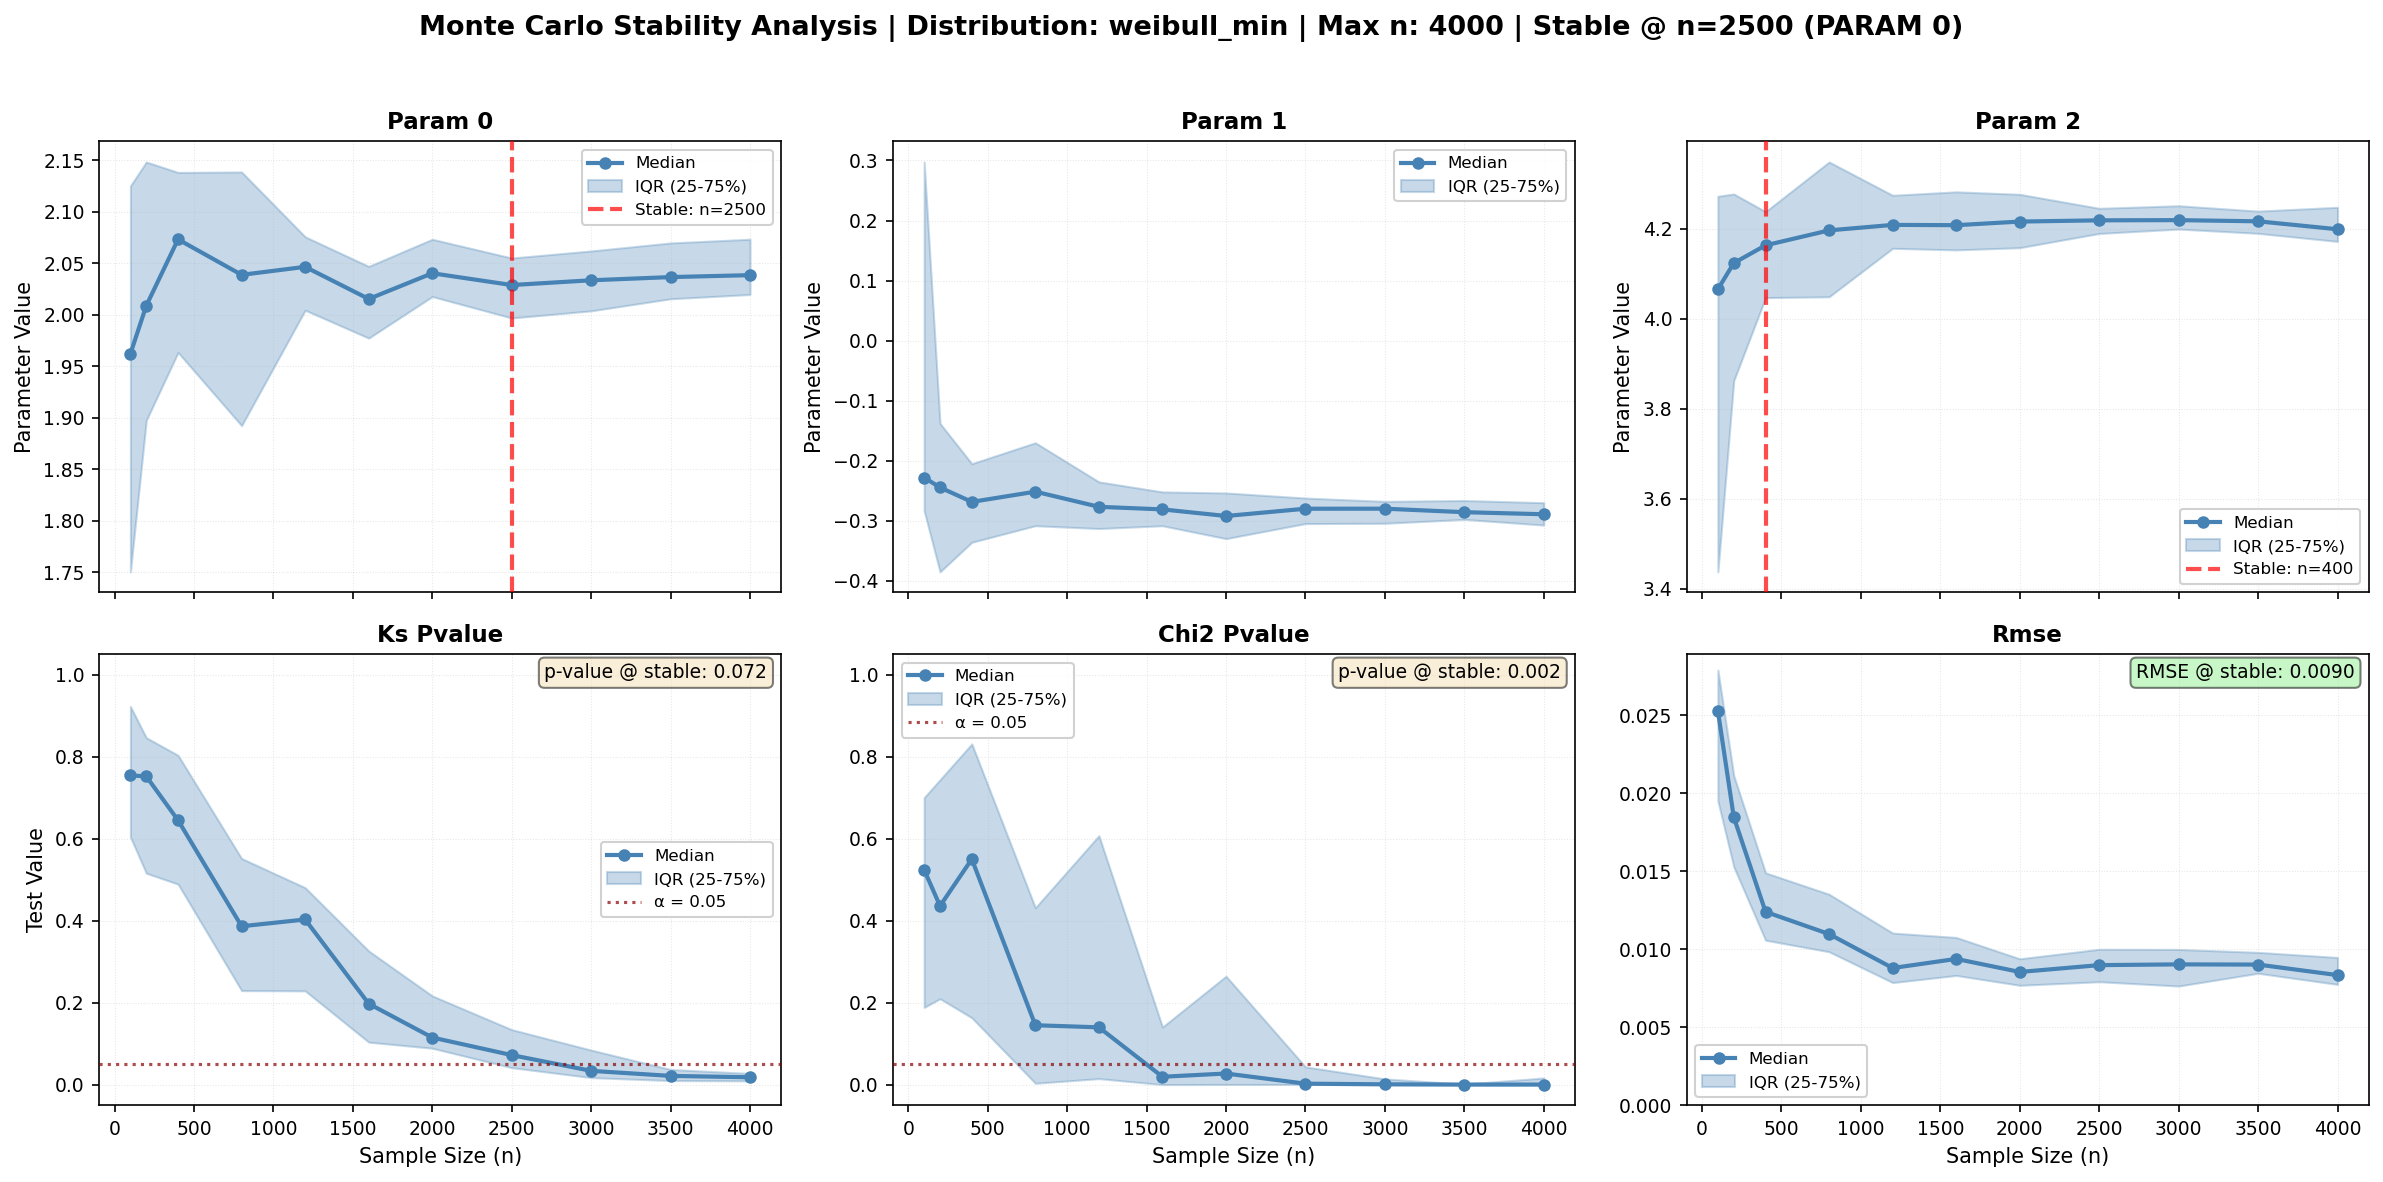



FIGURE INTERPRETATION:

🔍 What to Look For:

1. **Red Dashed Vertical Lines**: Detected stability points
   • Shows where each variable stabilizes according to the method
   • Different methods may place these at different locations

2. **Orange Dashed Lines** (Kneedle only): Smoothed median curve
   • Helps identify the 'elbow' point more clearly
   • Only visible when using Kneedle method with smoothing enabled

3. **RMSE Panel** (Bottom Right):
   • Typically shows clearest convergence behavior
   • Kneedle excels at finding the elbow in this curve
   • Look for where the curve flattens out

4. **Parameter Panels** (Top Row):
   • Should show convergence as n increases
   • IQR (shaded area) should decrease
   • Plateau detection works well here

5. **P-value Panels** (Bottom Left/Center):
   • Red dotted horizontal line at α = 0.05
   • Text box shows p-value at stable point
   • Can be erratic - CV method handles variability best


In [27]:
# Display figures side-by-side for visual comparison
from IPython.display import Image, display
import matplotlib.pyplot as plt

print("VISUAL COMPARISON OF METHODS")
print("=" * 80)
print("\nDisplaying generated figures for each method...\n")

for method_key, method_name in method_names.items():
    results = method_results[method_key]
    fig_path = results.attrs.get('figure_path')
    
    if fig_path:
        print(f"\n{method_name}:")
        print("-" * 80)
        display(Image(filename=fig_path))
        print()

print("\n" + "=" * 80)
print("FIGURE INTERPRETATION:")
print("=" * 80)
print("\n🔍 What to Look For:")
print("\n1. **Red Dashed Vertical Lines**: Detected stability points")
print("   • Shows where each variable stabilizes according to the method")
print("   • Different methods may place these at different locations")
print("\n2. **Orange Dashed Lines** (Kneedle only): Smoothed median curve")
print("   • Helps identify the 'elbow' point more clearly")
print("   • Only visible when using Kneedle method with smoothing enabled")
print("\n3. **RMSE Panel** (Bottom Right):")
print("   • Typically shows clearest convergence behavior")
print("   • Kneedle excels at finding the elbow in this curve")
print("   • Look for where the curve flattens out")
print("\n4. **Parameter Panels** (Top Row):")
print("   • Should show convergence as n increases")
print("   • IQR (shaded area) should decrease")
print("   • Plateau detection works well here")
print("\n5. **P-value Panels** (Bottom Left/Center):")
print("   • Red dotted horizontal line at α = 0.05")
print("   • Text box shows p-value at stable point")
print("   • Can be erratic - CV method handles variability best")

### Understanding Each Method

#### 1. Coefficient of Variation (CV) Method

**How it works:**
- Calculates std/mean across repeats for each sample size
- Looks for when CV stays consistently below 10% threshold
- Uses a sliding window to ensure stability is sustained

**Best for:**
- General purpose - works for all metrics
- P-values (which can be erratic)
- When you need robust, conservative estimates

**Parameters:**
- `window_size`: Number of consecutive sizes that must be stable (default: len(sizes)//4)
- `cv_threshold`: Maximum acceptable CV (default: 0.1 = 10%)

#### 2. Kneedle Algorithm

**How it works:**
- Based on Satopää et al. (2011) paper
- Normalizes curve to [0,1] range
- Finds maximum distance between curve and reference line (the "elbow")
- Optionally smooths curve first for clearer detection

**Best for:**
- RMSE (decreasing curves with clear elbow)
- Converging parameters
- When you want to find the "point of diminishing returns"

**Parameters:**
- `smooth`: Enable curve smoothing (default: True)
- `smoothing_method`: 'savgol' (default) or 'spline'

**Visual indicator:**
- Orange dashed line shows smoothed curve in figures

#### 3. Plateau Detection

**How it works:**
- Uses relative gain heuristic: Δᵢ = |y(i-1) - y(i)| / |y(i-1)|
- Detects when improvement becomes negligible
- Requires several consecutive points below threshold

**Best for:**
- Converging parameters
- Metrics with clear plateau behavior
- When you want early detection of "good enough"

**Parameters:**
- `consecutive_points`: L parameter - points that must satisfy criterion (default: 3)
- `relative_tolerance`: Δ parameter - maximum acceptable change (default: 0.01 = 1%)

In [28]:
# Demonstrate method-specific parameters
print("TESTING METHOD-SPECIFIC PARAMETERS")
print("=" * 80)
print("\nLet's see how parameter tuning affects detection...\n")

# Test Kneedle with different smoothing methods
print("1. Kneedle with different smoothing:")
print("-" * 40)

for smooth_method in ['savgol', 'spline']:
    results_smooth = large_processor.monte_carlo_fit(
        sizes=[100, 400, 800, 1500, 2500, 4000],
        n_repeats=20,
        tests=['rmse'],
        stability_method='kneedle',
        smooth=True,
        smoothing_method=smooth_method,
        seed=42
    )
    
    rmse_stable = results_smooth.attrs['stability_points']['rmse']['size']
    print(f"  {smooth_method:8s}: RMSE stabilizes at n = {rmse_stable}")

# Test Plateau with different tolerances
print("\n2. Plateau with different relative tolerances:")
print("-" * 40)

for tol in [0.005, 0.01, 0.02]:
    results_plateau = large_processor.monte_carlo_fit(
        sizes=[100, 400, 800, 1500, 2500, 4000],
        n_repeats=20,
        tests=['rmse'],
        stability_method='plateau',
        relative_tolerance=tol,
        consecutive_points=3,
        seed=42
    )
    
    rmse_stable = results_plateau.attrs['stability_points']['rmse'].get('size', 'Not detected')
    print(f"  Δ = {tol:.3f} (tol = {tol*100:.1f}%): RMSE stabilizes at n = {rmse_stable}")

# Test CV with different thresholds
print("\n3. CV with different thresholds:")
print("-" * 40)

for cv_thresh in [0.05, 0.10, 0.15]:
    results_cv = large_processor.monte_carlo_fit(
        sizes=[100, 400, 800, 1500, 2500, 4000],
        n_repeats=20,
        tests=['rmse'],
        stability_method='cv',
        cv_threshold=cv_thresh,
        seed=42
    )
    
    rmse_stable = results_cv.attrs['stability_points']['rmse'].get('size', 'Not detected')
    print(f"  CV < {cv_thresh:.2f} ({cv_thresh*100:.0f}%): RMSE stabilizes at n = {rmse_stable}")

print("\n💡 KEY INSIGHTS:")
print("   • Stricter thresholds → Later detection (more conservative)")
print("   • Looser thresholds → Earlier detection (more aggressive)")
print("   • Savgol smoothing preserves features better than spline")
print("   • Choose parameters based on your application's needs")

TESTING METHOD-SPECIFIC PARAMETERS

Let's see how parameter tuning affects detection...

1. Kneedle with different smoothing:
----------------------------------------


Monte Carlo sizes: 100%|██████████| 6/6 [00:01<00:00,  3.91it/s]



  savgol  : RMSE stabilizes at n = 400


Monte Carlo sizes: 100%|██████████| 6/6 [00:01<00:00,  3.88it/s]



  spline  : RMSE stabilizes at n = 1500

2. Plateau with different relative tolerances:
----------------------------------------


...

  CV < 0.05 (5%): RMSE stabilizes at n = None


Monte Carlo sizes: 100%|██████████| 6/6 [00:01<00:00,  4.23it/s]



  CV < 0.10 (10%): RMSE stabilizes at n = None


Monte Carlo sizes: 100%|██████████| 6/6 [00:01<00:00,  3.68it/s]

  CV < 0.15 (15%): RMSE stabilizes at n = 2500

💡 KEY INSIGHTS:
   • Stricter thresholds → Later detection (more conservative)
   • Looser thresholds → Earlier detection (more aggressive)
   • Savgol smoothing preserves features better than spline
   • Choose parameters based on your application's needs


### Method Selection Guide

Use this table to choose the best method for your analysis:

| Your Metric | Recommended Method | Why |
|------------|-------------------|-----|
| **RMSE** | `kneedle` | Clear decreasing curve with distinct elbow point |
| **Parameters (converging)** | `kneedle` or `plateau` | Both work well for convergence detection |
| **KS p-value** | `cv` | Can be erratic; CV handles variability robustly |
| **Chi² p-value** | `cv` | Can be erratic; CV handles variability robustly |
| **Mixed metrics** | `cv` | General purpose, works for everything |
| **Need early detection** | `plateau` | Detects "good enough" earlier |
| **Need conservative estimate** | `cv` | More stringent criteria |

### Real-World Workflow Recommendations

#### For Production Analysis:
```python
# Use Kneedle with RMSE - most reliable
results = processor.monte_carlo_fit(
    tests=['ks', 'chi2', 'rmse'],
    stability_method='kneedle',
    n_repeats=50,
    fig_output_path='stability_analysis.png'
)
```

#### For Exploratory Analysis:
```python
# Use CV - robust and general
results = processor.monte_carlo_fit(
    tests=['rmse'],
    stability_method='cv',
    n_repeats=30
)
```

#### For Quick Assessment:
```python
# Use Plateau - faster, often detects earlier
results = processor.monte_carlo_fit(
    tests=['rmse'],
    stability_method='plateau',
    n_repeats=20,
    relative_tolerance=0.02  # 2% change threshold
)
```

#### When Unsure - Compare Methods:
```python
# Run all three and compare
for method in ['cv', 'kneedle', 'plateau']:
    results = processor.monte_carlo_fit(
        tests=['rmse'],
        stability_method=method,
        fig_output_path=f'stability_{method}.png'
    )
    print(f"{method}: n = {results.attrs['recommended_size']}")
```

PRACTICAL EXAMPLE: Using Kneedle for RMSE Analysis

This is the recommended approach for most cases.



Monte Carlo sizes: 100%|██████████| 11/11 [00:09<00:00,  1.20it/s]



RESULTS:
--------------------------------------------------------------------------------
Recommended sample size: n = 800
Based on: RMSE

Stability points by metric:
  rmse           : n =        800 (method: kneedle)
  ks_pvalue      : n =       2000 (method: kneedle)
  chi2_pvalue    : n =       1200 (method: kneedle)
  param_0        : n =        800 (method: kneedle)

Quality at stable point (n = 800):
  RMSE:        0.010839
  KS p-value:  0.3755
  χ² p-value:  0.1192

Figure saved to: final_stability_analysis.png



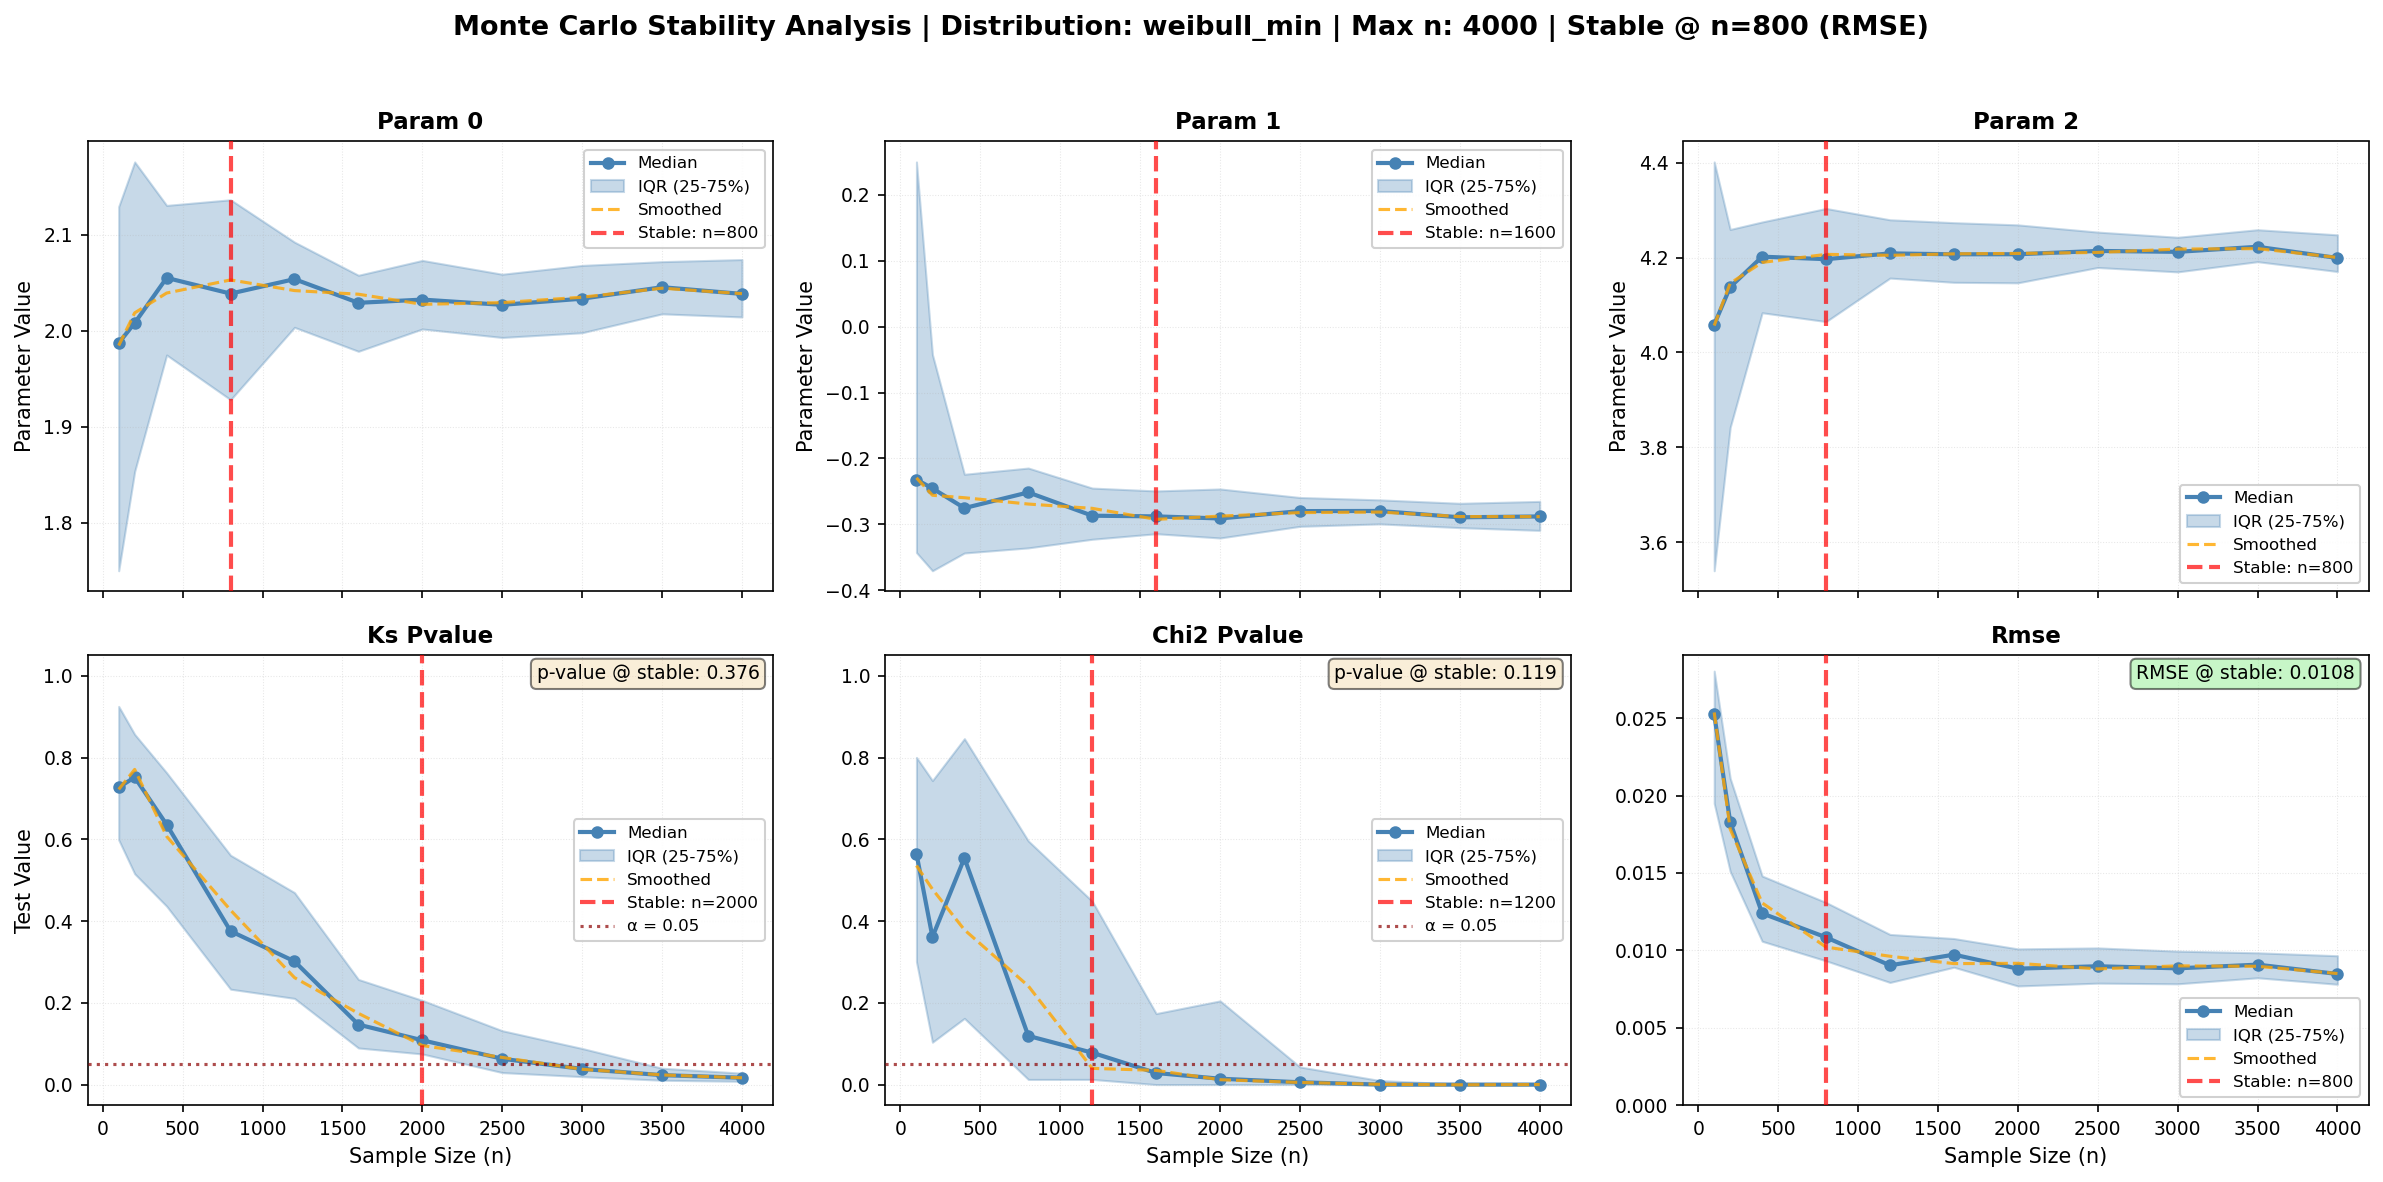


✅ SUCCESS!
   This figure shows:
   • Orange dashed lines: Smoothed curves (Kneedle's preprocessing)
   • Red vertical lines: Detected stability points
   • Informative title: Distribution, max n, and recommended stable point
   • Quality metrics: P-values and RMSE at the stable point

   Use n = 800 for robust inference!


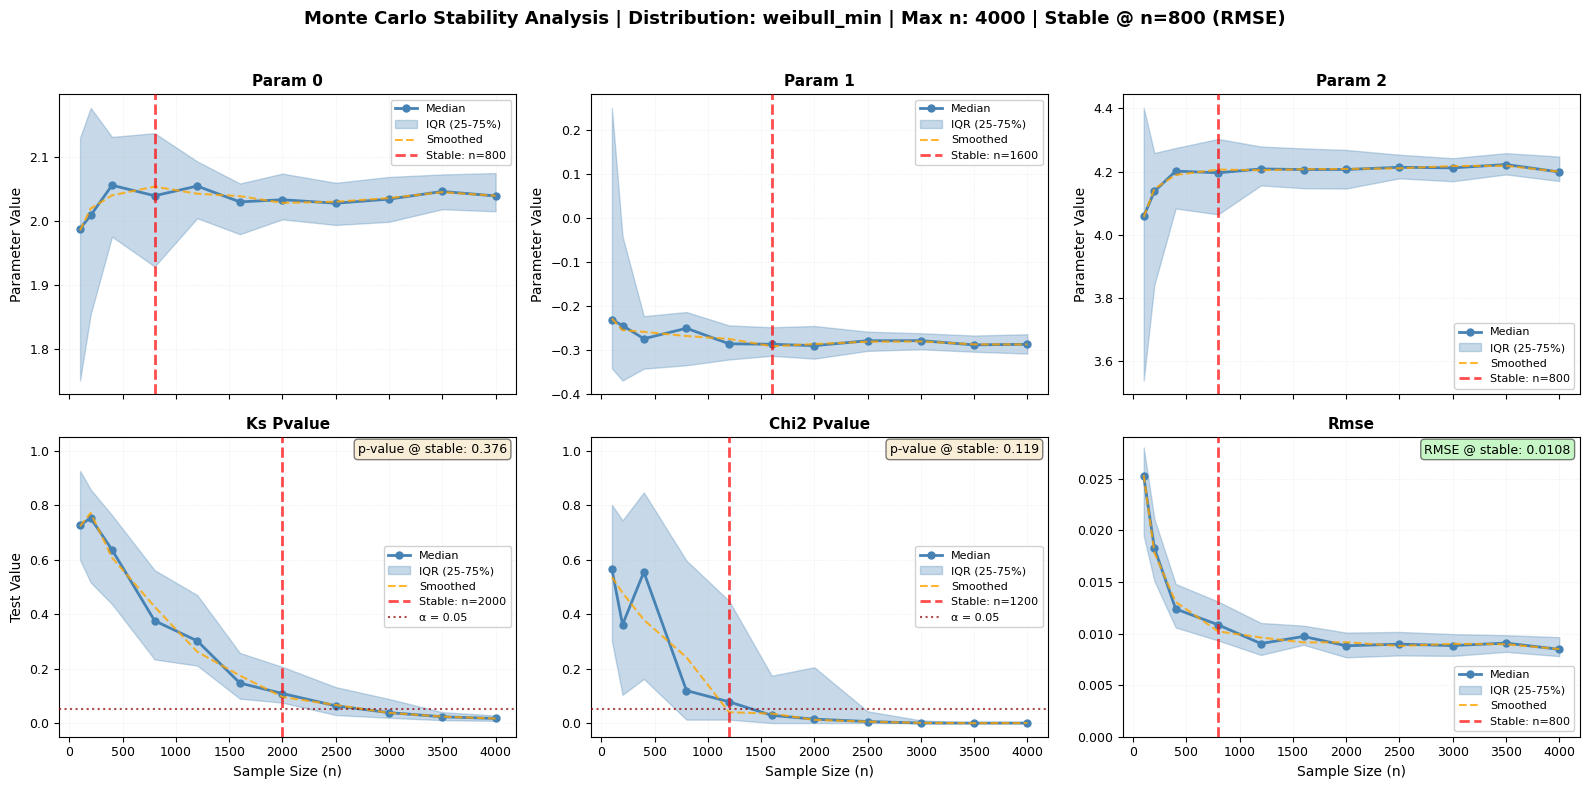

In [29]:
# Practical example: Use the best method for RMSE
print("PRACTICAL EXAMPLE: Using Kneedle for RMSE Analysis")
print("=" * 80)
print("\nThis is the recommended approach for most cases.\n")

# Run with Kneedle method
final_results = large_processor.monte_carlo_fit(
    sizes=[100, 200, 400, 800, 1200, 1600, 2000, 2500, 3000, 3500, 4000],
    n_repeats=50,
    tests=['ks', 'chi2', 'rmse'],
    stability_method='kneedle',
    smooth=True,
    smoothing_method='savgol',
    sampling='random',
    seed=42,
    fig_output_path='final_stability_analysis.png',
    plot_type='series'
)

# Extract key information
recommended_n = final_results.attrs['recommended_size']
primary_metric = final_results.attrs['primary_metric']
stability_points = final_results.attrs['stability_points']

print("RESULTS:")
print("-" * 80)
print(f"Recommended sample size: n = {recommended_n}")
print(f"Based on: {primary_metric.upper()}")
print(f"\nStability points by metric:")

for metric in ['rmse', 'ks_pvalue', 'chi2_pvalue', 'param_0']:
    if metric in stability_points:
        info = stability_points[metric]
        size = info.get('size', 'Not detected')
        method = info.get('method', 'N/A')
        print(f"  {metric:15s}: n = {size:10} (method: {method})")

# Display quality metrics at stable point
print(f"\nQuality at stable point (n = {recommended_n}):")
if final_results.attrs.get('stable_rmse') is not None:
    print(f"  RMSE:        {final_results.attrs['stable_rmse']:.6f}")
if final_results.attrs.get('stable_pvalue_ks') is not None:
    print(f"  KS p-value:  {final_results.attrs['stable_pvalue_ks']:.4f}")
if final_results.attrs.get('stable_pvalue_chi2') is not None:
    print(f"  χ² p-value:  {final_results.attrs['stable_pvalue_chi2']:.4f}")

print(f"\nFigure saved to: {final_results.attrs['figure_path']}")

# Display the final figure
print("\n" + "=" * 80)
display(Image(filename=final_results.attrs['figure_path']))

print("\n✅ SUCCESS!")
print("   This figure shows:")
print("   • Orange dashed lines: Smoothed curves (Kneedle's preprocessing)")
print("   • Red vertical lines: Detected stability points")
print("   • Informative title: Distribution, max n, and recommended stable point")
print("   • Quality metrics: P-values and RMSE at the stable point")
print(f"\n   Use n = {recommended_n} for robust inference!")

## Summary and Best Practices

### Key Points:

1. **Data Loading**: Use `ma.read_data()` to create a `DataProcessor`
2. **Distribution Fitting**: Use `.fit_distribution(distribution_name)` 
3. **Direct Method Access**: All SciPy methods available directly (pdf, cdf, ppf, etc.)
4. **Smart Defaults**: Methods like `pdf()` and `cdf()` use original data when no input provided
5. **Goodness-of-Fit**: Use `.goodness_of_fit()` with 'ks', 'chi2', or 'rmse'
6. **Bin Selection**: Chi-square test supports multiple binning methods ('doane', 'sturges', etc.)
7. **Constraints**: Pass fitting constraints as keyword arguments (e.g., `floc=0`)
8. **Stability Analysis**: Use `monte_carlo_fit()` with automatic figure generation
9. **Large Sample Effects**: For n>5000, use Monte Carlo CPS method to avoid p-value inflation
10. **⭐ RMSE for Stability**: RMSE shows clearest convergence - use it as primary stability indicator

### Recommended Workflows:

#### Standard Analysis (n < 5000):
```python
# 1. Load data
processor = ma.read_data(your_data)

# 2. Fit distribution
processor.fit_distribution('weibull_min')

# 3. Evaluate fit quality with appropriate binning
ks_test = processor.goodness_of_fit('ks')
chi2_test = processor.goodness_of_fit('chi2', bins='doane')  # Choose bins wisely!

# 4. Use fitted distribution
percentile_95 = processor.ppf(0.95)
probability = processor.cdf(threshold_value)

# 5. Run stability analysis with automatic plotting
# IMPORTANT: Include 'rmse' for best stability detection
mc_results = processor.monte_carlo_fit(
    n_repeats=30,
    tests=['ks', 'chi2', 'rmse'],  # RMSE is crucial!
    fig_output_path='stability_analysis.png',
    plot_type='series'
)

# 6. Use RMSE-based stability point (most reliable)
optimal_size = mc_results.attrs['stability_points']['rmse'].get('size')
```

#### Large Dataset Analysis (n > 5000):
```python
# 1. Load data
processor = ma.read_data(large_dataset)

# 2. Run CPS analysis with automatic visualization
# Always include RMSE for clearest stability detection
mc_results = processor.monte_carlo_fit(
    sizes=[100, 200, 500, 1000, 2000],  # Test multiple subsample sizes
    n_repeats=50,
    tests=['ks', 'chi2', 'rmse'],  # RMSE shows best convergence behavior
    sampling='random',
    fig_output_path='cps_analysis.png',  # Auto-generates 2x3 summary plot
    plot_type='series'
)

# 3. Check RMSE stability point (most reliable indicator)
rmse_stability = mc_results.attrs['stability_points']['rmse']
optimal_size = rmse_stability.get('size', mc_results.attrs['recommended_size'])
print(f"Optimal size from RMSE: {optimal_size}")

# 4. Use recommended subsample size for robust inference
# ... split data into subsamples of optimal_size ...
```

### Important Considerations:

- **⭐ RMSE is King**: RMSE typically shows much clearer convergence than p-values
  - P-values can be erratic and unreliable for stability detection
  - RMSE decreases smoothly and shows clear stabilization points
  - **Always include 'rmse' in your tests list** for Monte Carlo analysis
  
- **Chi-square binning**: Different methods can significantly affect results - choose appropriately

- **Large samples**: P-values become unreliable with very large datasets (n>10,000)

- **CPS method**: Helps separate statistical significance from practical significance

- **Sampling strategy**: 
  - 'random': general purpose, independent draws
  - 'bootstrap': with replacement, good for uncertainty estimation
  - 'disjoint': non-overlapping, better for temporal/spatial data

- **Reproducibility**: Always set random seeds for Monte Carlo analyses

- **Automatic plotting**: Use `fig_output_path` parameter to generate publication-ready figures

- **Plot types**: 'series' shows medians with IQR, 'boxplots' shows distribution per size

### Monte Carlo Analysis Features:

The `monte_carlo_fit()` method provides:

1. **Automatic figure generation**: Set `fig_output_path` to save a 2x3 summary plot
2. **Stability detection**: Automatically identifies where parameters/tests stabilize
3. **Multiple tests**: Run KS, Chi-square, and **RMSE** tests simultaneously
4. **Flexible sampling**: Choose between random, bootstrap, or disjoint strategies
5. **Parameter tracking**: Monitor how all distribution parameters evolve with sample size
6. **Recommended size**: Get a suggested optimal subsample size based on stability

### 🎯 Best Practice - Stability Detection:

**Use RMSE as your primary stability indicator:**

1. RMSE shows smooth, monotonic decrease as sample size increases
2. Stabilization point is clearly visible (when curve flattens)
3. More reliable than p-values which can fluctuate
4. Directly measures fit quality improvement

**Visual cue in plots:**
- Look at bottom-right panel (RMSE)
- Find where curve flattens (red dashed line)
- This is your optimal sample size!

For automatic distribution selection, see the AutoFitter tutorial!